## FEATURE ENGINEERING


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("force2020_cleaned.csv")
curves = ["RHOB", "GR", "NPHI", "PEF", "DTC"]
units = {"RHOB": "g/cc", "GR": "API", "NPHI": "v/v", "PEF": "b/e", "DTC": "us/ft"}

complete = df[curves].notna().all(axis=1)
print(f"Rows in the well: {len(df):,}")
print(f"Rows with all five curves: {complete.sum():,}")
print(f"Depth range of those rows: {df.loc[complete, 'DEPTH_MD'].min():.1f} to {df.loc[complete, 'DEPTH_MD'].max():.1f} m")


Rows in the well: 18,270
Rows with all five curves: 12,018
Depth range of those rows: 1138.7 to 2993.9 m


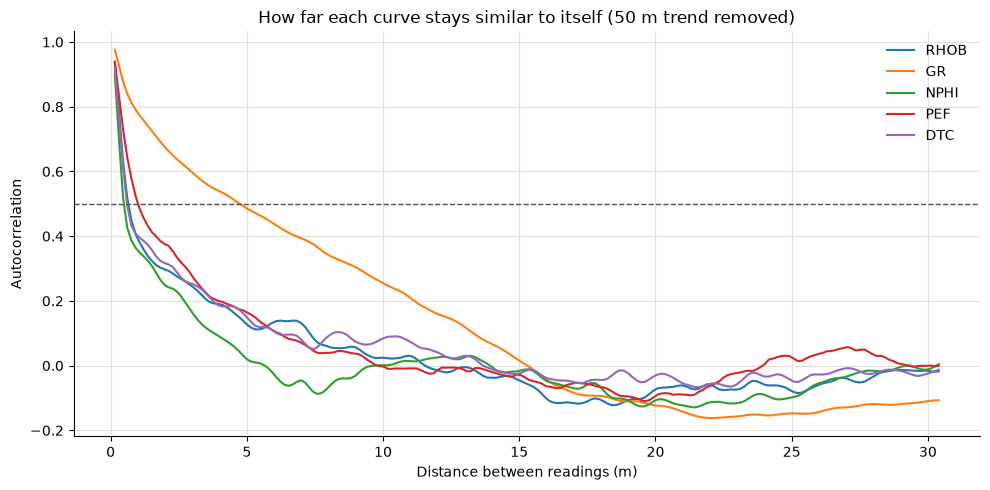

RHOB    0.8
GR      4.9
NPHI    0.6
PEF     1.1
DTC     0.6
Name: correlation_length_m, dtype: float64

In [3]:
step = df["DEPTH_MD"].diff().median()
lags = np.arange(1, 201)
trend_window = int(50 / step) | 1

fig, ax = plt.subplots(figsize=(10, 5))
lengths = {}
for col in curves:
    trend = df[col].rolling(trend_window, center=True, min_periods=trend_window // 3).median()
    detrended = df[col] - trend
    ac = np.array([detrended.autocorr(lag) for lag in lags])
    lengths[col] = lags[np.argmax(ac < 0.5)] * step
    ax.plot(lags * step, ac, linewidth=1.5, label=col)
ax.axhline(0.5, color="#52514e", linestyle="--", linewidth=1)
ax.set_xlabel("Distance between readings (m)")
ax.set_ylabel("Autocorrelation")
ax.set_title("How far each curve stays similar to itself (50 m trend removed)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(color="#e1e0d9")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

pd.Series(lengths, name="correlation_length_m").round(1)


In [4]:
gr_smooth = df["GR"].rolling(window=7, center=True).median()

comparison = pd.DataFrame({
    "DEPTH_MD": df["DEPTH_MD"],
    "GR_raw": df["GR"],
    "GR_smooth_1m": gr_smooth,
})
comparison.iloc[5000:5010]


,DEPTH_MD,GR_raw,GR_smooth_1m
5000,1254.528,67.644791,69.428314
5001,1254.680,68.852013,68.852013
5002,1254.832,69.428314,68.737984
5003,1254.984,68.737984,67.870338
5004,1255.136,67.870338,67.870338
5005,1255.288,67.411201,67.411201
5006,1255.440,67.183578,67.183578
5007,1255.592,62.971294,62.971294
5008,1255.744,59.407070,62.971294
5009,1255.896,58.052666,62.971294


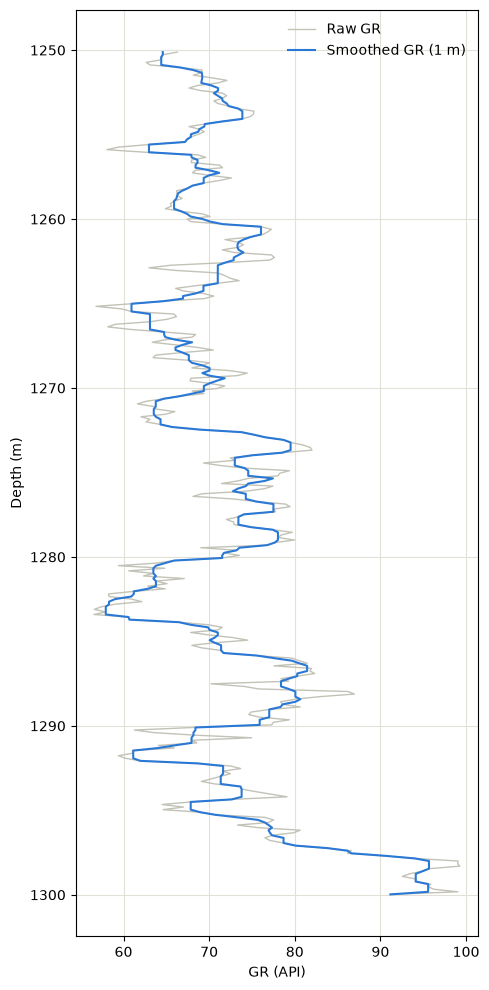

In [5]:
zoom = comparison[comparison["DEPTH_MD"].between(1250, 1300)]

fig, ax = plt.subplots(figsize=(5, 10))
ax.plot(zoom["GR_raw"], zoom["DEPTH_MD"], color="#c3c2b7", linewidth=1, label="Raw GR")
ax.plot(zoom["GR_smooth_1m"], zoom["DEPTH_MD"], color="#2a78d6", linewidth=1.5, label="Smoothed GR (1 m)")
ax.set_xlabel("GR (API)")
ax.set_ylabel("Depth (m)")
ax.invert_yaxis()
ax.legend(frameon=False)
ax.grid(color="#e1e0d9")
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


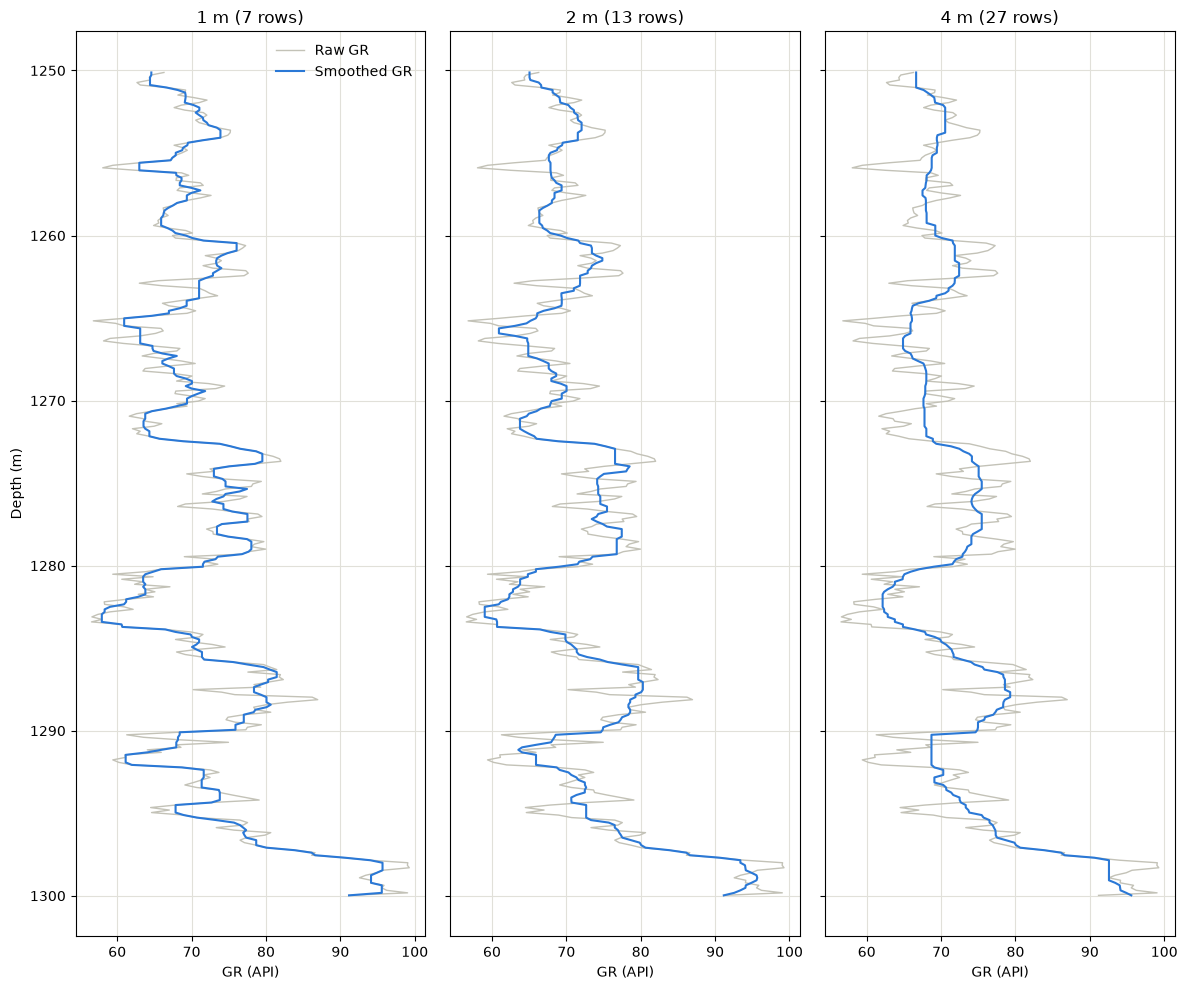

In [6]:
sizes = {"1 m (7 rows)": 7, "2 m (13 rows)": 13, "4 m (27 rows)": 27}

fig, axes = plt.subplots(1, len(sizes), figsize=(12, 10), sharey=True)
for ax, (label, size) in zip(axes, sizes.items()):
    smooth = df["GR"].rolling(window=size, center=True).median()
    zoom = df["DEPTH_MD"].between(1250, 1300)
    ax.plot(df.loc[zoom, "GR"], df.loc[zoom, "DEPTH_MD"], color="#c3c2b7", linewidth=1, label="Raw GR")
    ax.plot(smooth[zoom], df.loc[zoom, "DEPTH_MD"], color="#2a78d6", linewidth=1.5, label="Smoothed GR")
    ax.set_title(label)
    ax.set_xlabel("GR (API)")
    ax.grid(color="#e1e0d9")
    ax.set_axisbelow(True)
axes[0].set_ylabel("Depth (m)")
axes[0].invert_yaxis()
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()


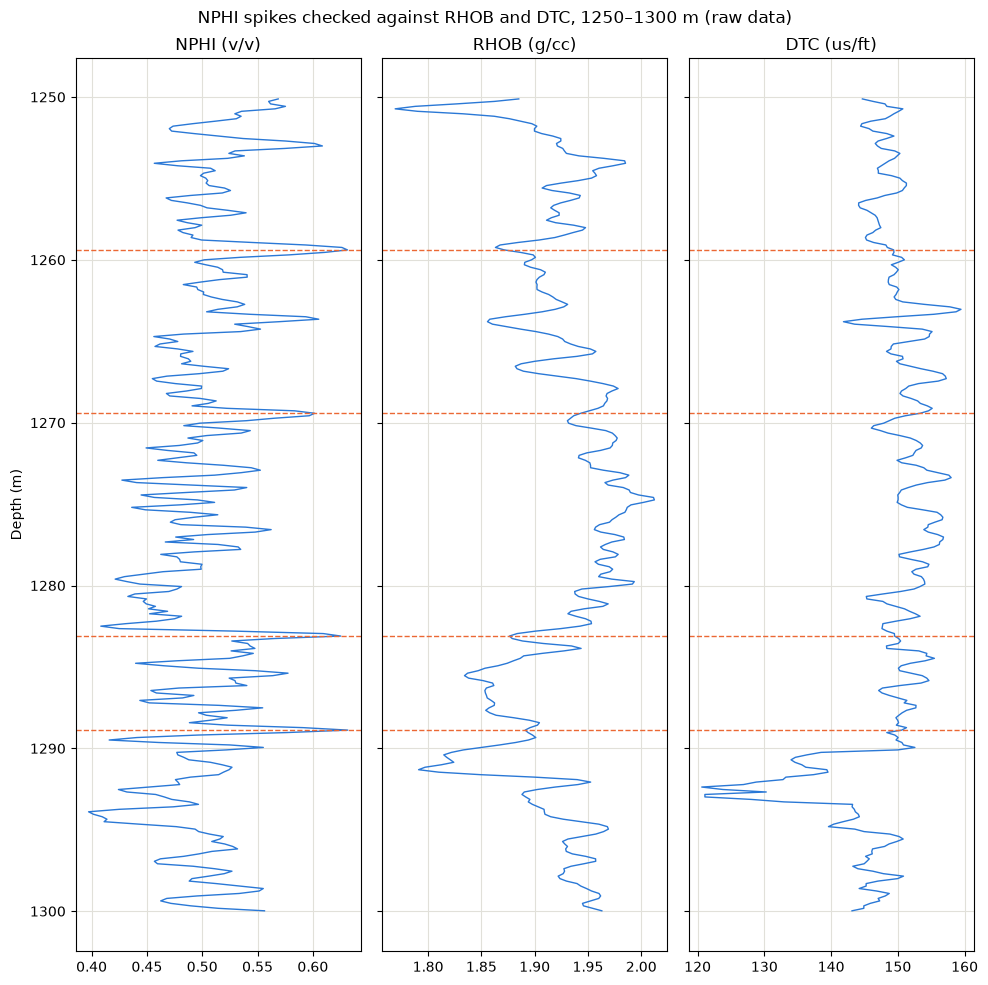

In [7]:
zoom = df["DEPTH_MD"].between(1250, 1300)
nphi_spikes = [1259.4, 1269.4, 1283.1, 1288.9]
check_curves = ["NPHI", "RHOB", "DTC"]

fig, axes = plt.subplots(1, len(check_curves), figsize=(10, 10), sharey=True)
for ax, col in zip(axes, check_curves):
    ax.plot(df.loc[zoom, col], df.loc[zoom, "DEPTH_MD"], color="#2a78d6", linewidth=1)
    for depth in nphi_spikes:
        ax.axhline(depth, color="#eb6834", linewidth=1, linestyle="--")
    ax.set_title(f"{col} ({units[col]})")
    ax.grid(color="#e1e0d9")
    ax.set_axisbelow(True)
axes[0].set_ylabel("Depth (m)")
axes[0].invert_yaxis()
fig.suptitle("NPHI spikes checked against RHOB and DTC, 1250–1300 m (raw data)")
plt.tight_layout()
plt.show()


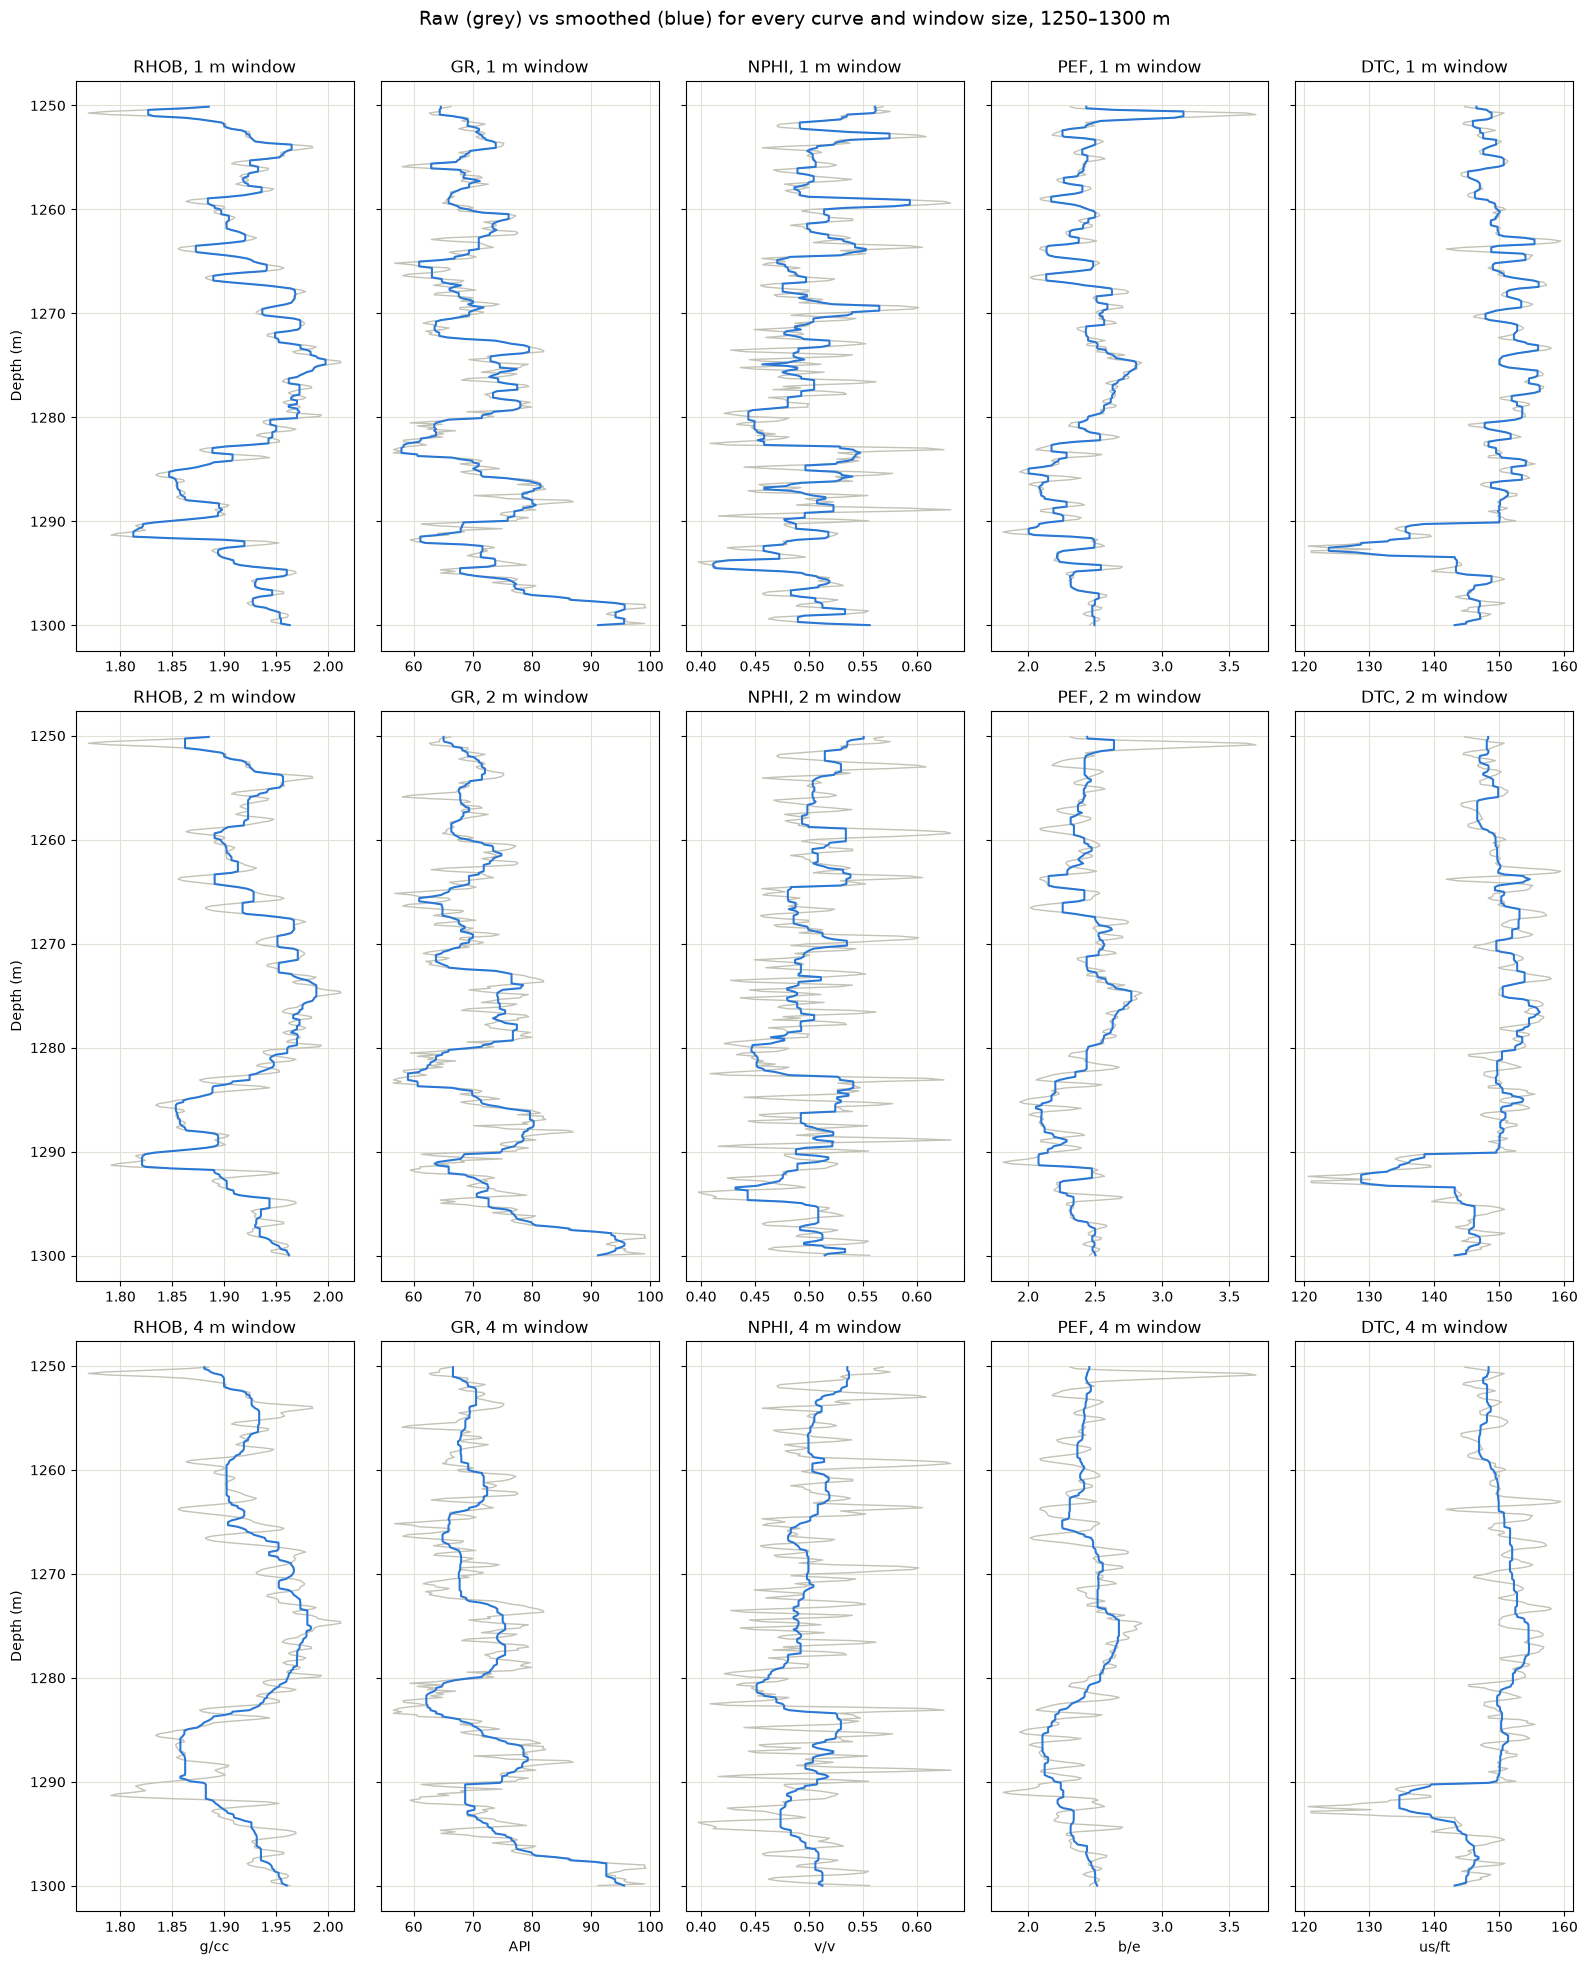

In [8]:
sizes = {"1 m": 7, "2 m": 13, "4 m": 27}
zoom = df["DEPTH_MD"].between(1250, 1300)

fig, axes = plt.subplots(len(sizes), len(curves), figsize=(16, 20), sharey=True)
for row, (label, size) in enumerate(sizes.items()):
    for col_i, col in enumerate(curves):
        ax = axes[row, col_i]
        smooth = df[col].rolling(window=size, center=True).median()
        ax.plot(df.loc[zoom, col], df.loc[zoom, "DEPTH_MD"], color="#c3c2b7", linewidth=1)
        ax.plot(smooth[zoom], df.loc[zoom, "DEPTH_MD"], color="#2a78d6", linewidth=1.5)
        ax.set_title(f"{col}, {label} window")
        ax.grid(color="#e1e0d9")
        ax.set_axisbelow(True)
        if row == len(sizes) - 1:
            ax.set_xlabel(units[col])
    axes[row, 0].set_ylabel("Depth (m)")
axes[0, 0].invert_yaxis()
fig.suptitle("Raw (grey) vs smoothed (blue) for every curve and window size, 1250–1300 m", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


In [9]:
window = 27

features = df[["DEPTH_MD"] + curves].copy()
for col in curves:
    features[f"{col}_4m"] = df[col].rolling(window=window, center=True, min_periods=window // 2 + 1).median()

print(features.shape)
print("Blank values per column:")
print(features.isna().sum())
features.iloc[5000:5005]


(18270, 11)
Blank values per column:
DEPTH_MD       0
RHOB         976
GR             0
NPHI        4238
PEF         3033
DTC         1057
RHOB_4m     1017
GR_4m          0
NPHI_4m     4238
PEF_4m      2999
DTC_4m      1098
dtype: int64


,DEPTH_MD,RHOB,GR,NPHI,PEF,DTC,RHOB_4m,GR_4m,NPHI_4m,PEF_4m,DTC_4m
5000,1254.528,1.954443,67.644791,0.511711,2.339673,147.076431,1.933589,69.510811,0.507588,2.414887,148.296417
5001,1254.680,1.956509,68.852013,0.501283,2.352703,147.067047,1.933589,69.428314,0.506216,2.420626,148.099152
5002,1254.832,1.958009,69.428314,0.498384,2.441563,149.045868,1.933589,69.428314,0.504997,2.420626,148.099152
5003,1254.984,1.953255,68.737984,0.503205,2.544164,150.298981,1.933589,69.428314,0.504997,2.420626,148.099152
5004,1255.136,1.940861,67.870338,0.504997,2.572559,150.677689,1.933589,68.852013,0.504997,2.420626,148.099152


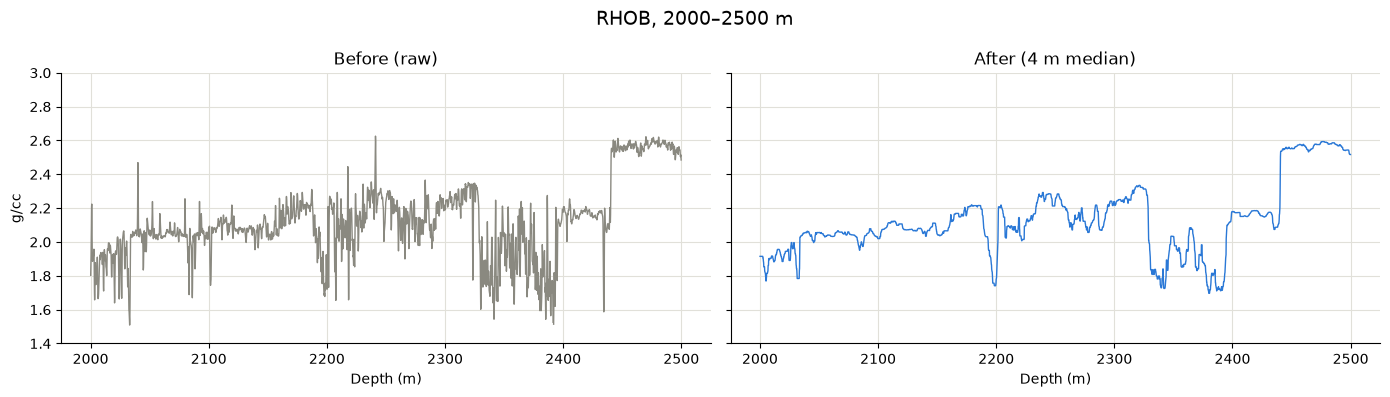

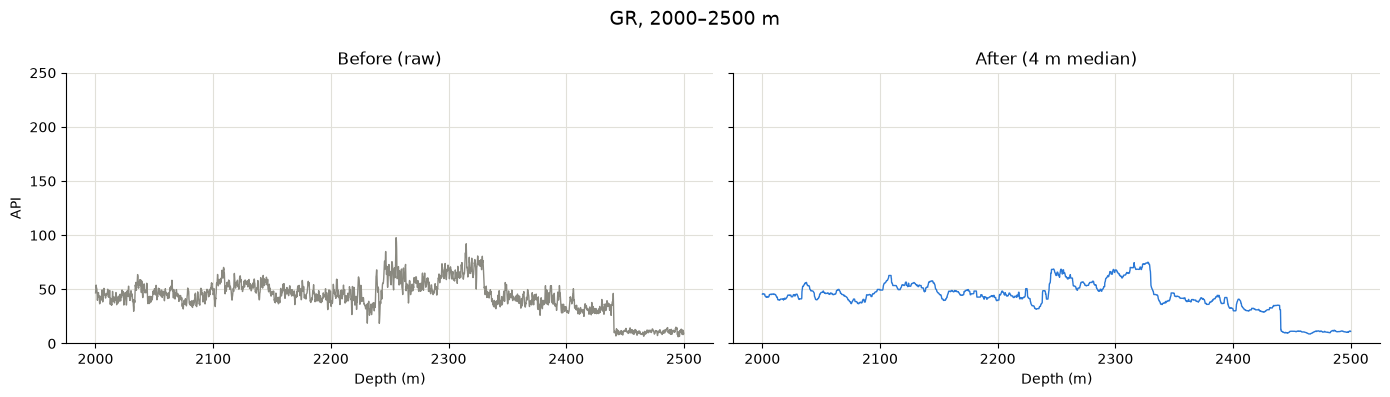

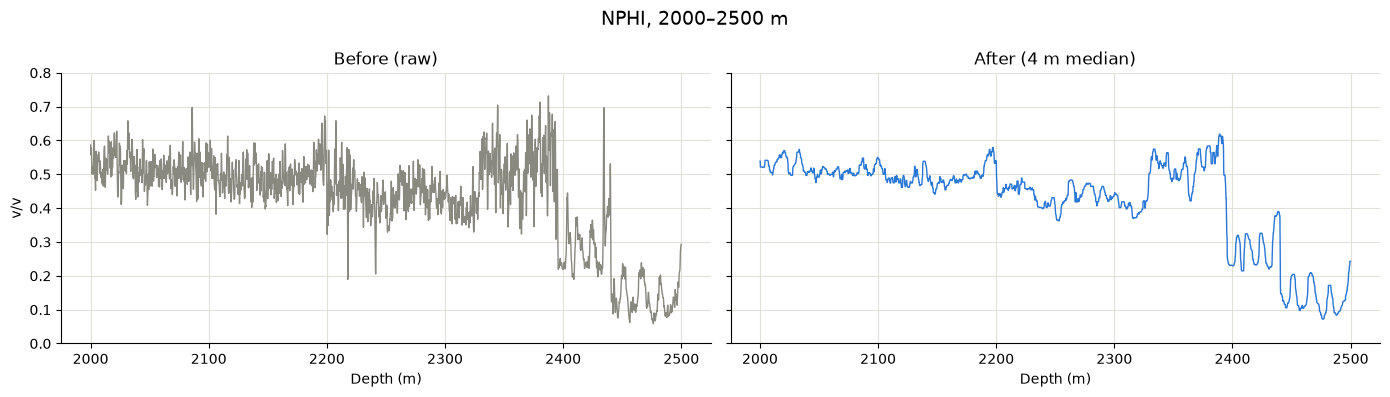

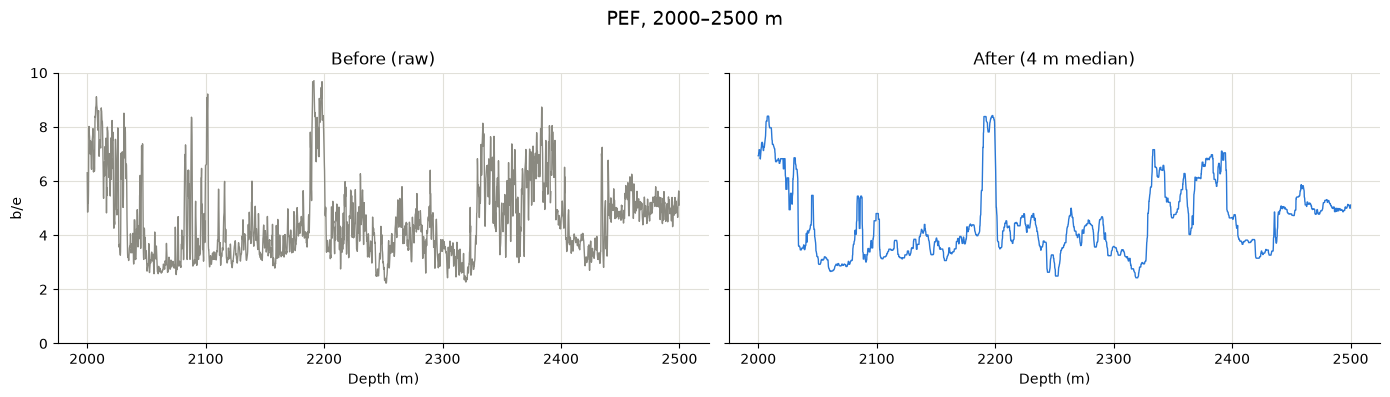

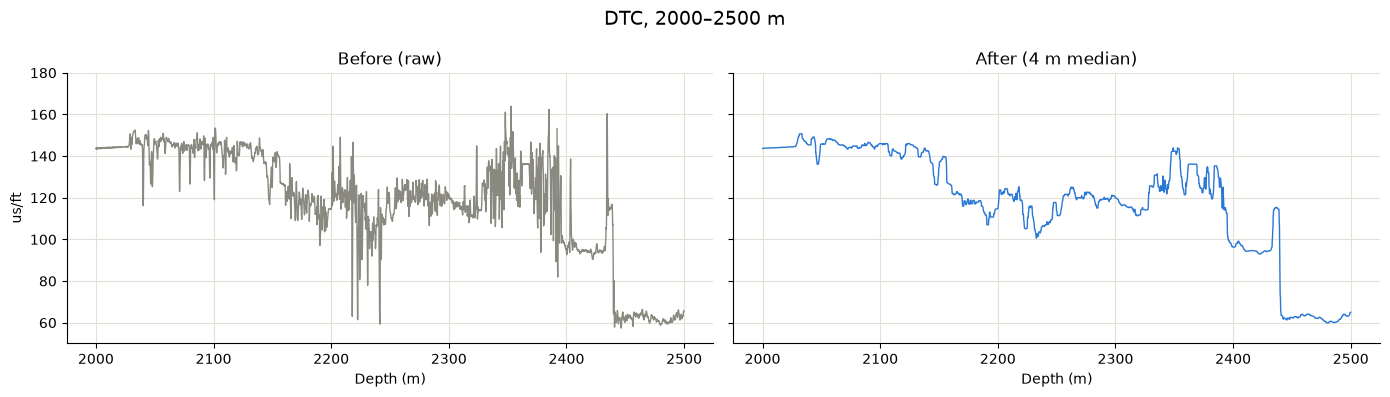

In [10]:
track_range = {"RHOB": (1.4, 3.0), "GR": (0, 250), "NPHI": (0, 0.8), "PEF": (0, 10), "DTC": (50, 180)}
top, bottom = 2000, 2500

show = features["DEPTH_MD"].between(top, bottom)
for col in curves:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    for ax, (name, column, color) in zip(axes, [("Before (raw)", col, "#8a8980"),
                                                ("After (4 m median)", f"{col}_4m", "#2a78d6")]):
        ax.plot(features.loc[show, "DEPTH_MD"], features.loc[show, column], color=color, linewidth=1)
        ax.set_ylim(track_range[col])
        ax.set_title(name, fontsize=12)
        ax.set_xlabel("Depth (m)")
        ax.grid(color="#e1e0d9")
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
    axes[0].set_ylabel(units[col])
    fig.suptitle(f"{col}, {top}–{bottom} m", fontsize=14)
    plt.tight_layout()
    plt.show()


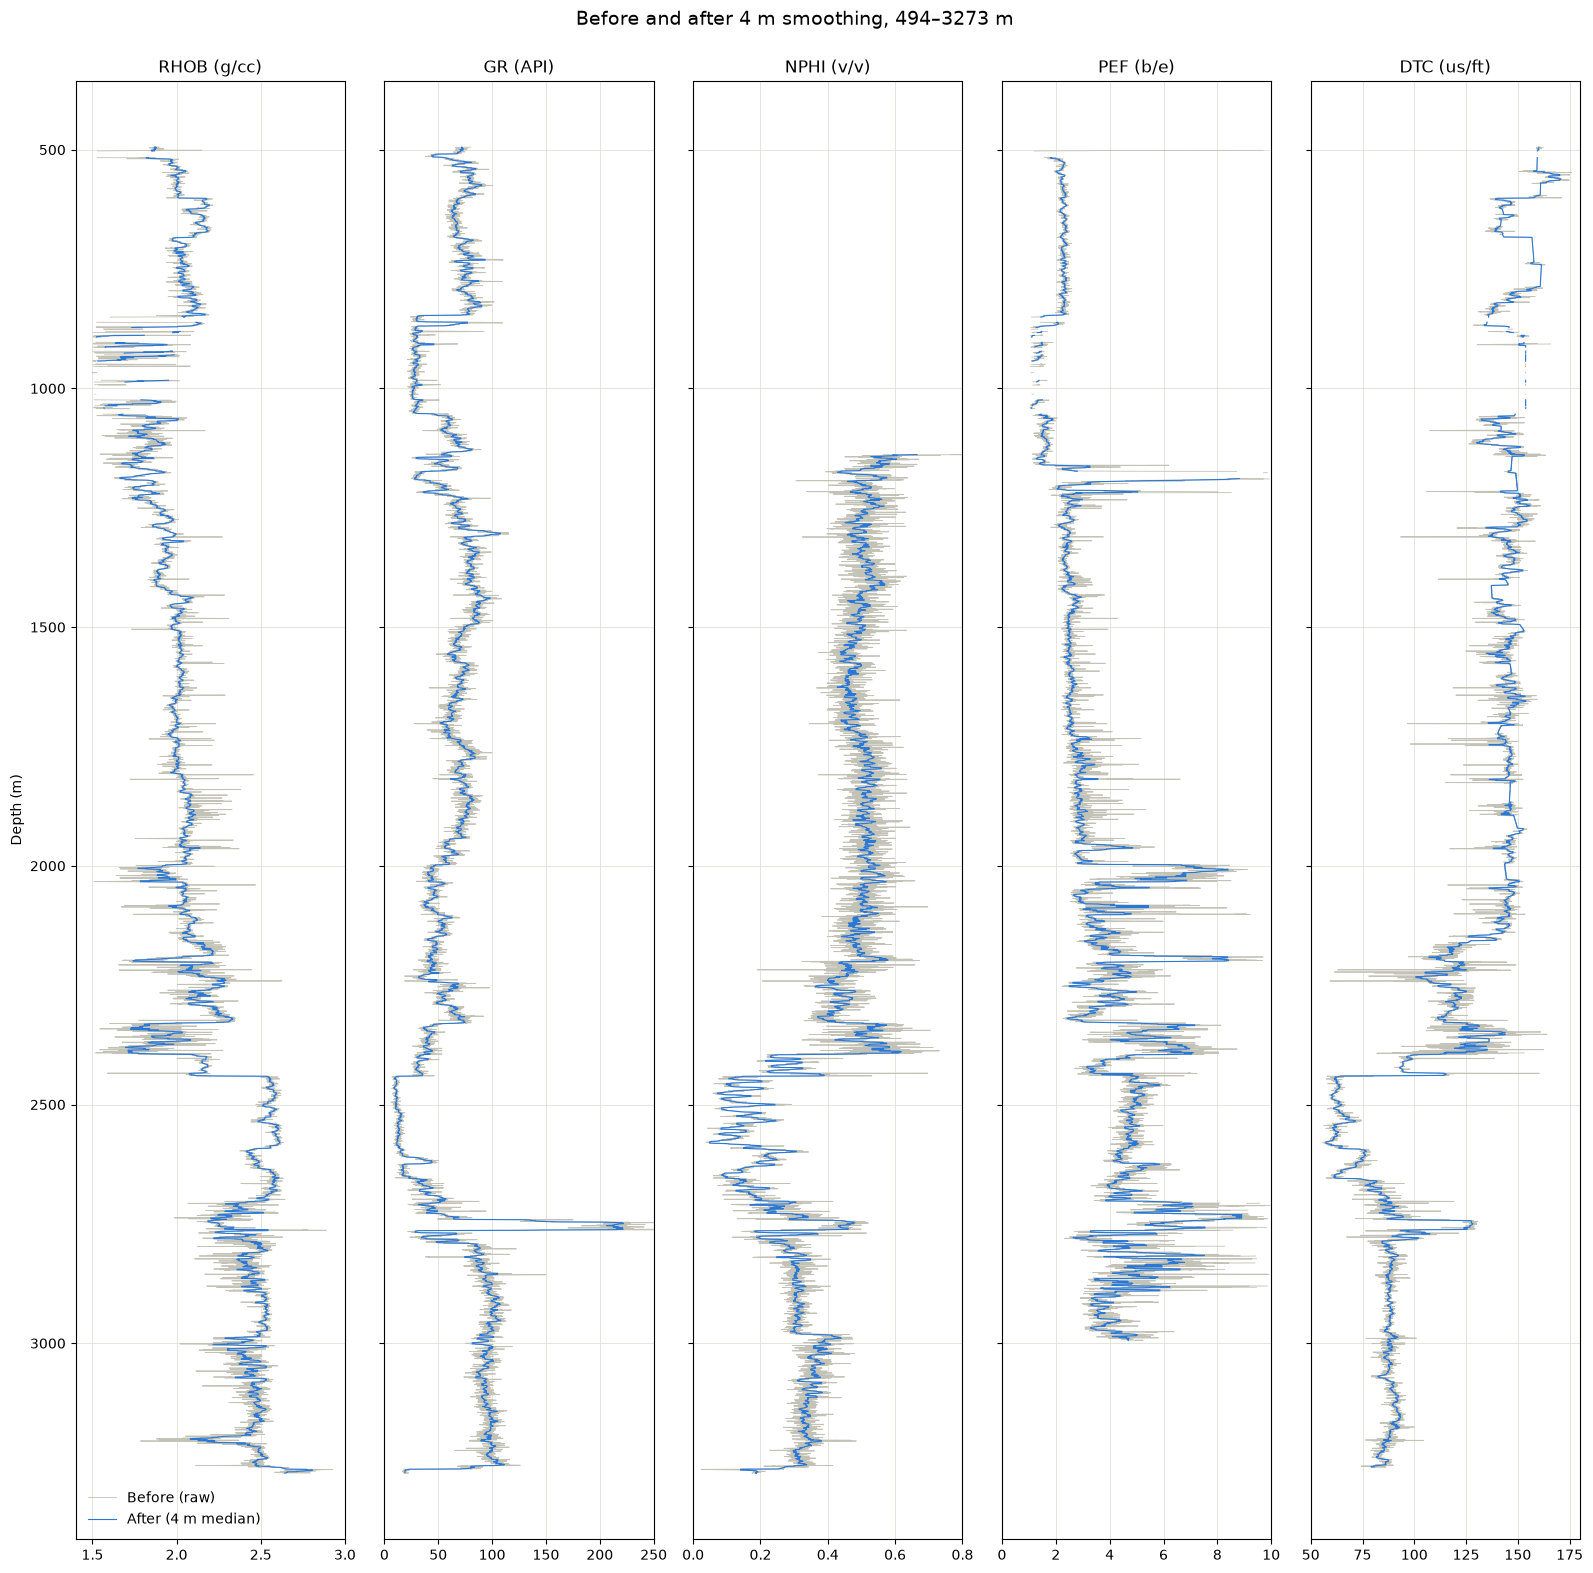

In [11]:
track_range = {"RHOB": (1.4, 3.0), "GR": (0, 250), "NPHI": (0, 0.8), "PEF": (0, 10), "DTC": (50, 180)}
top, bottom = 494, 3273

show = features["DEPTH_MD"].between(top, bottom)
fig, axes = plt.subplots(1, len(curves), figsize=(16, 16), sharey=True)
for ax, col in zip(axes, curves):
    ax.plot(features.loc[show, col], features.loc[show, "DEPTH_MD"], color="#c3c2b7", linewidth=0.6, label="Before (raw)")
    ax.plot(features.loc[show, f"{col}_4m"], features.loc[show, "DEPTH_MD"], color="#2a78d6", linewidth=0.8, label="After (4 m median)")
    ax.set_xlim(track_range[col])
    ax.set_title(f"{col} ({units[col]})")
    ax.grid(color="#e1e0d9", linewidth=0.6)
    ax.set_axisbelow(True)
axes[0].set_ylabel("Depth (m)")
axes[0].invert_yaxis()
axes[0].legend(frameon=False, loc="lower left")
fig.suptitle(f"Before and after 4 m smoothing, {top}–{bottom} m", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


In [12]:
from sklearn.preprocessing import RobustScaler

smooth_cols = [f"{col}_4m" for col in curves]

scaler = RobustScaler()
scaled = pd.DataFrame(
    scaler.fit_transform(features[smooth_cols]),
    columns=smooth_cols,
    index=features.index,
)

print(scaled.describe().round(2))


        RHOB_4m     GR_4m   NPHI_4m    PEF_4m    DTC_4m
count  17253.00  18270.00  14032.00  15271.00  17172.00
mean       0.21     -0.09     -0.30      0.28     -0.30
std        0.58      0.74      0.68      0.74      0.54
min       -1.26     -1.57     -2.16     -0.92     -1.46
25%       -0.17     -0.63     -0.77     -0.24     -0.90
50%        0.00      0.00      0.00      0.00      0.00
75%        0.83      0.37      0.23      0.76      0.10
max        1.74      4.17      1.07      3.15      0.52


In [13]:
model_rows = scaled.notna().all(axis=1)
X = scaled[model_rows]

print("Rows going into clustering:", len(X))
print("Rows left out (have a blank):", (~model_rows).sum())
print("Depth range:", features.loc[model_rows, "DEPTH_MD"].min(), "–", features.loc[model_rows, "DEPTH_MD"].max(), "m")


Rows going into clustering: 12104
Rows left out (have a blank): 6166
Depth range: 1138.704 – 2993.864 m


In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    sil = silhouette_score(X, km.labels_, sample_size=5000, random_state=42)
    results.append({"k": k, "inertia": round(km.inertia_, 1), "silhouette": round(sil, 3)})

kmeans_scores = pd.DataFrame(results)
kmeans_scores


,k,inertia,silhouette
0,2,14162.3,0.524
1,3,9644.2,0.573
2,4,6484.0,0.562
3,5,5198.4,0.569
4,6,3980.8,0.505
5,7,3440.5,0.504
6,8,2950.6,0.485


In [15]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42).fit(X)

features.loc[model_rows, "kmeans"] = kmeans.labels_

profile = features.loc[model_rows].groupby("kmeans")[curves].median().round(2)
profile["rows"] = features.loc[model_rows, "kmeans"].value_counts().sort_index()
profile


,RHOB,GR,NPHI,PEF,DTC,rows
kmeans,,,,,,
0.0,2.02,68.81,0.50,2.68,145.54,6787
1.0,2.54,17.17,0.17,4.70,70.48,2280
2.0,1.99,43.20,0.50,5.47,126.15,1501
3.0,2.48,96.60,0.31,4.38,88.45,1536


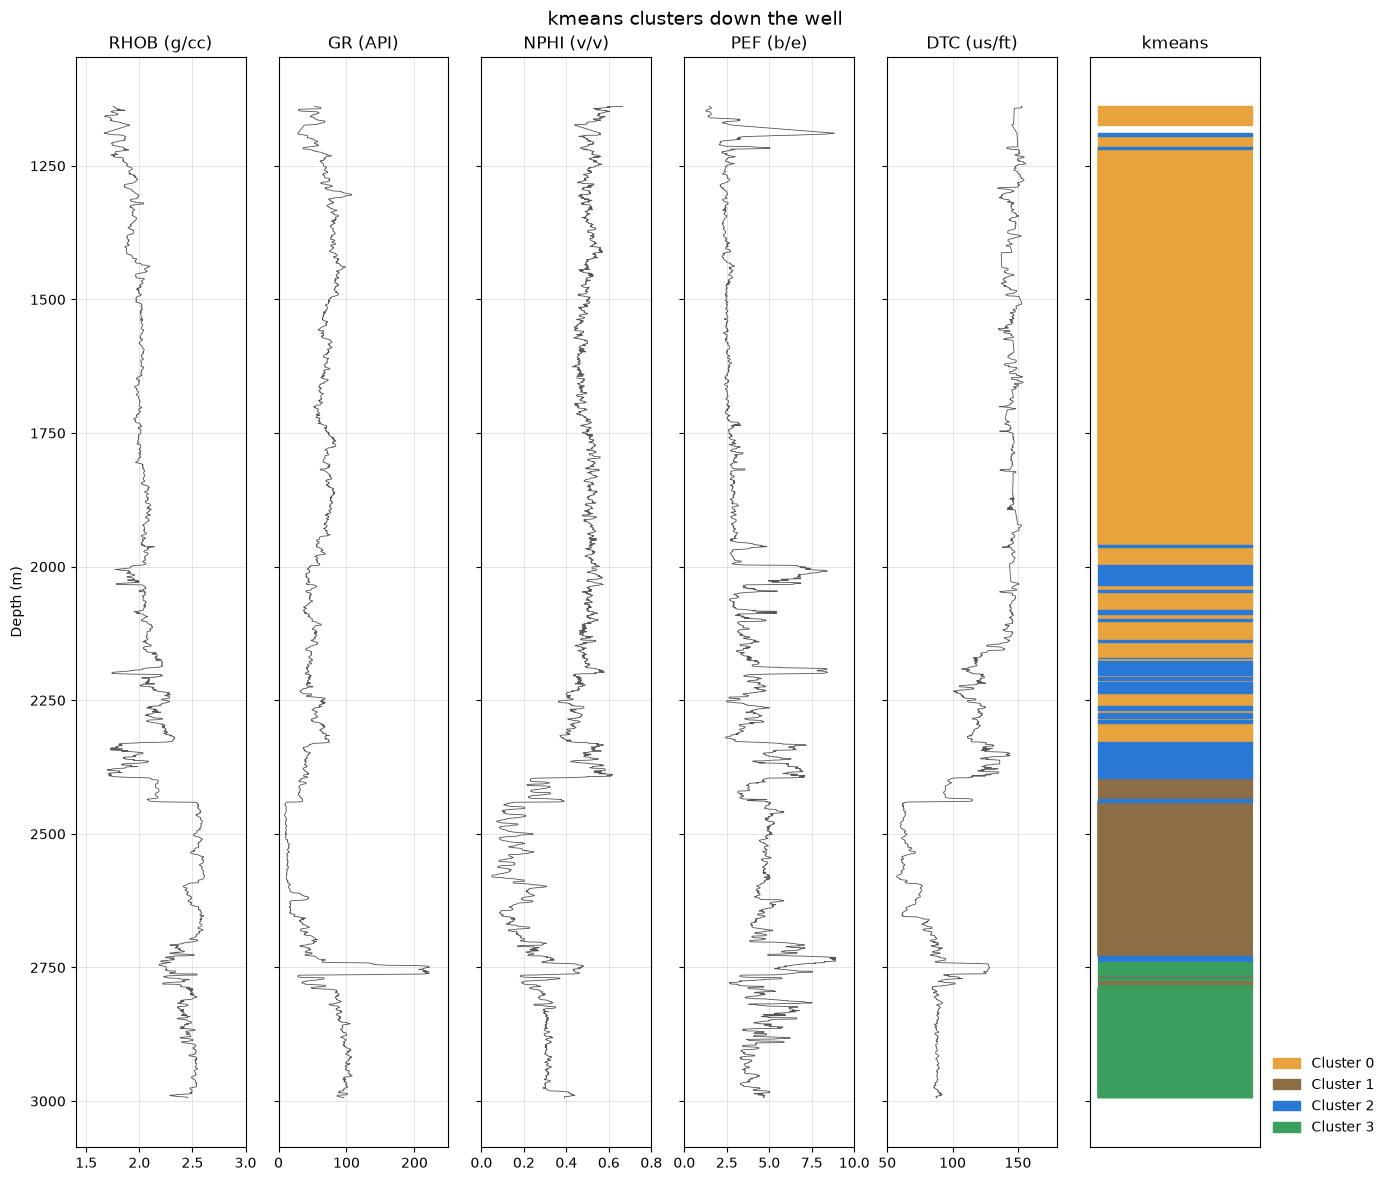

In [16]:
cluster_colors = {-1: "#bdbdbd", 0: "#e8a33d", 1: "#8c6d46", 2: "#2a78d6", 3: "#3a9e5f"}
track_range = {"RHOB": (1.4, 3.0), "GR": (0, 250), "NPHI": (0, 0.8), "PEF": (0, 10), "DTC": (50, 180)}

def plot_well(method):
    rows = features[model_rows]
    depth = rows["DEPTH_MD"]
    fig, axes = plt.subplots(1, len(curves) + 1, figsize=(14, 12), sharey=True)
    for ax, col in zip(axes, curves):
        ax.plot(rows[f"{col}_4m"], depth, color="#555555", linewidth=0.6)
        ax.set_xlim(track_range[col])
        ax.set_title(f"{col} ({units[col]})")
        ax.grid(color="#e1e0d9", linewidth=0.6)
    strip = axes[-1]
    for label in sorted(rows[method].unique()):
        strip.fill_betweenx(depth, 0, 1, where=rows[method] == label,
                            color=cluster_colors[int(label)], label=f"Cluster {int(label)}")
    strip.set_xticks([])
    strip.set_title(method)
    strip.legend(loc="lower left", bbox_to_anchor=(1, 0), frameon=False)
    axes[0].set_ylabel("Depth (m)")
    axes[0].invert_yaxis()
    fig.suptitle(f"{method} clusters down the well", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_well("kmeans")


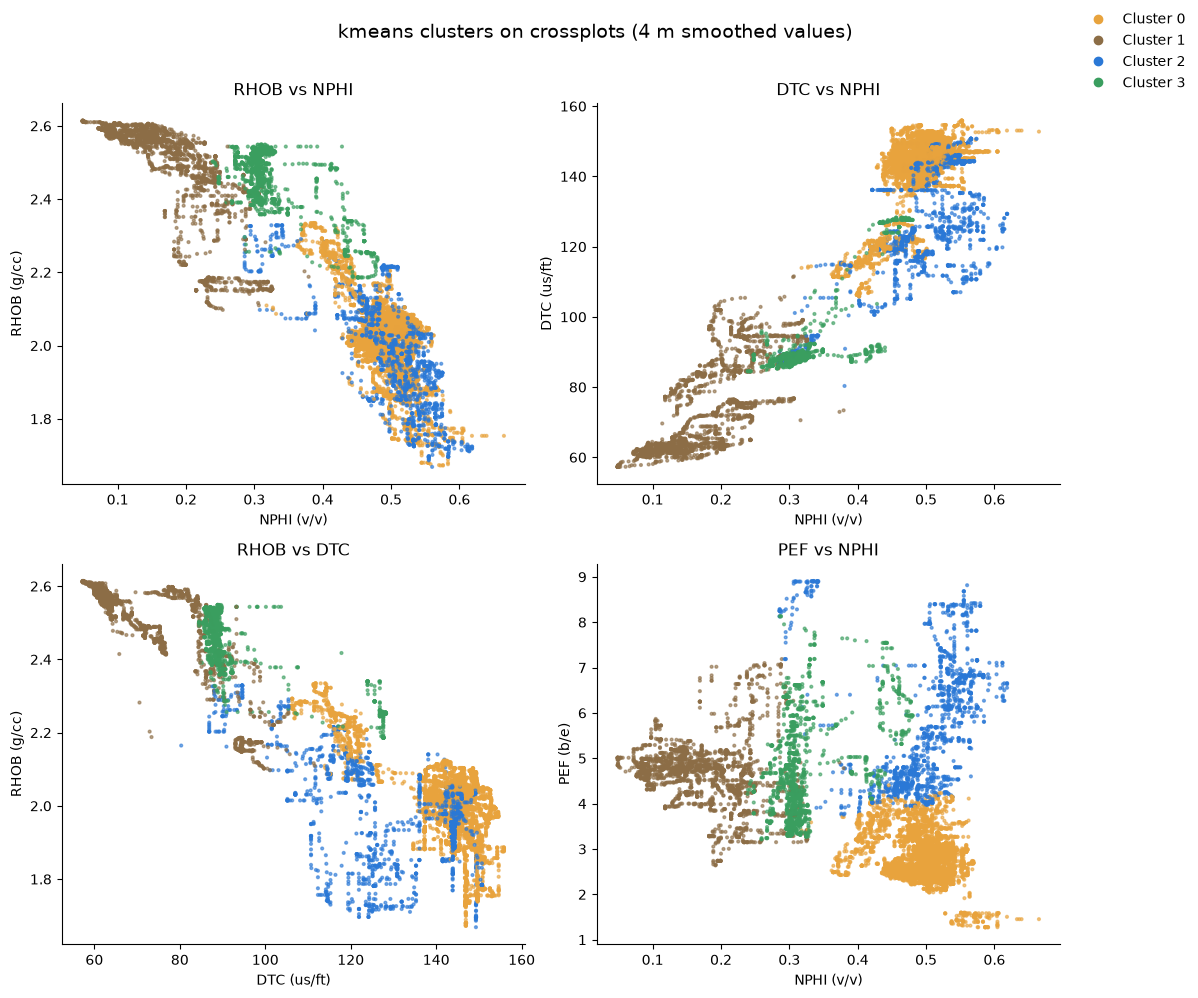

In [17]:
from matplotlib.lines import Line2D

pairs = [("NPHI", "RHOB"), ("NPHI", "DTC"), ("DTC", "RHOB"), ("NPHI", "PEF")]

def plot_crossplots(method):
    rows = features[model_rows]
    labels = sorted(rows[method].unique())
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    for ax, (x, y) in zip(axes.flat, pairs):
        ax.scatter(rows[f"{x}_4m"], rows[f"{y}_4m"],
                   c=rows[method].map(cluster_colors), s=4, alpha=0.6)
        ax.set_xlabel(f"{x} ({units[x]})")
        ax.set_ylabel(f"{y} ({units[y]})")
        ax.set_title(f"{y} vs {x}")
        ax.spines[["top", "right"]].set_visible(False)
    handles = [Line2D([], [], marker="o", linestyle="", color=cluster_colors[int(label)],
                      label=f"Cluster {int(label)}") for label in labels]
    fig.legend(handles=handles, loc="upper right", frameon=False)
    fig.suptitle(f"{method} clusters on crossplots (4 m smoothed values)", fontsize=14)
    plt.tight_layout(rect=[0, 0, 0.9, 0.97])
    plt.show()

plot_crossplots("kmeans")


### KMeans summary

**Preparation.** Readings sit **0.152 m apart** (measured from DEPTH_MD, not assumed). A **4 m window = 27 rows**
(13 above, the row itself, 13 below), and each depth takes the **median** of its 27 values, so one wild reading
can't drag it. The window slides **1 row at a time**, so every depth keeps a value. Effect: wobbles under ~2 m
are flattened, real layers stay. The curves were then **RobustScaled** so GR's big numbers don't outweigh
NPHI's small ones. Clustering can't take blanks, so only the **12,202 rows with all 5 curves** (1138.7–2993.9 m)
went in. Nothing was deleted.

**Result.** KMeans saw only the 5 curves, never depth. Of k = 2–8, **k = 4** scored best (silhouette 0.607).

| Cluster | Estimated rock | Pattern | Where |
|---|---|---|---|
| 1 | Soft shale | light 2.02, porous 0.49, slow 145 | 1139–2395 m |
| 2 | Limestone / chalk | dense 2.54, GR 17, fast 71 | 2395–2740 m |
| 3 | Compacted shale | dense 2.48, GR 97 | 2740–2994 m |
| 0 | **Bad readings** | lightest 1.88 but PEF 7.1 | scattered bands |

The clusters still came out as depth sections, so the boundaries at **~2395 m** and **~2740 m** are real.
Cluster 0 sits on the EDA's PEF > 10 spikes → **cleaning list**. Rock names are interpretations, not labels.


In [18]:
from sklearn.mixture import GaussianMixture

results = []
for k in range(2, 9):
    gm = GaussianMixture(n_components=k, n_init=3, random_state=42).fit(X)
    sil = silhouette_score(X, gm.predict(X), sample_size=5000, random_state=42)
    results.append({"k": k, "bic": round(gm.bic(X)), "silhouette": round(sil, 3)})

gmm_scores = pd.DataFrame(results)
gmm_scores


,k,bic,silhouette
0,2,28694,0.529
1,3,3602,0.391
2,4,-6997,0.441
3,5,-17658,0.408
4,6,-19702,0.399
5,7,-26734,0.424
6,8,-29755,0.396


In [19]:
gmm = GaussianMixture(n_components=4, n_init=3, random_state=42).fit(X)

features.loc[model_rows, "gmm"] = gmm.predict(X)

profile = features.loc[model_rows].groupby("gmm")[curves].median().round(2)
profile["rows"] = features.loc[model_rows, "gmm"].value_counts().sort_index()
profile


,RHOB,GR,NPHI,PEF,DTC,rows
gmm,,,,,,
0.0,2.01,71.46,0.50,2.61,146.04,5358
1.0,2.55,15.10,0.16,4.68,65.74,1928
2.0,2.05,48.09,0.49,4.07,129.01,2890
3.0,2.47,93.47,0.30,4.55,88.21,1928


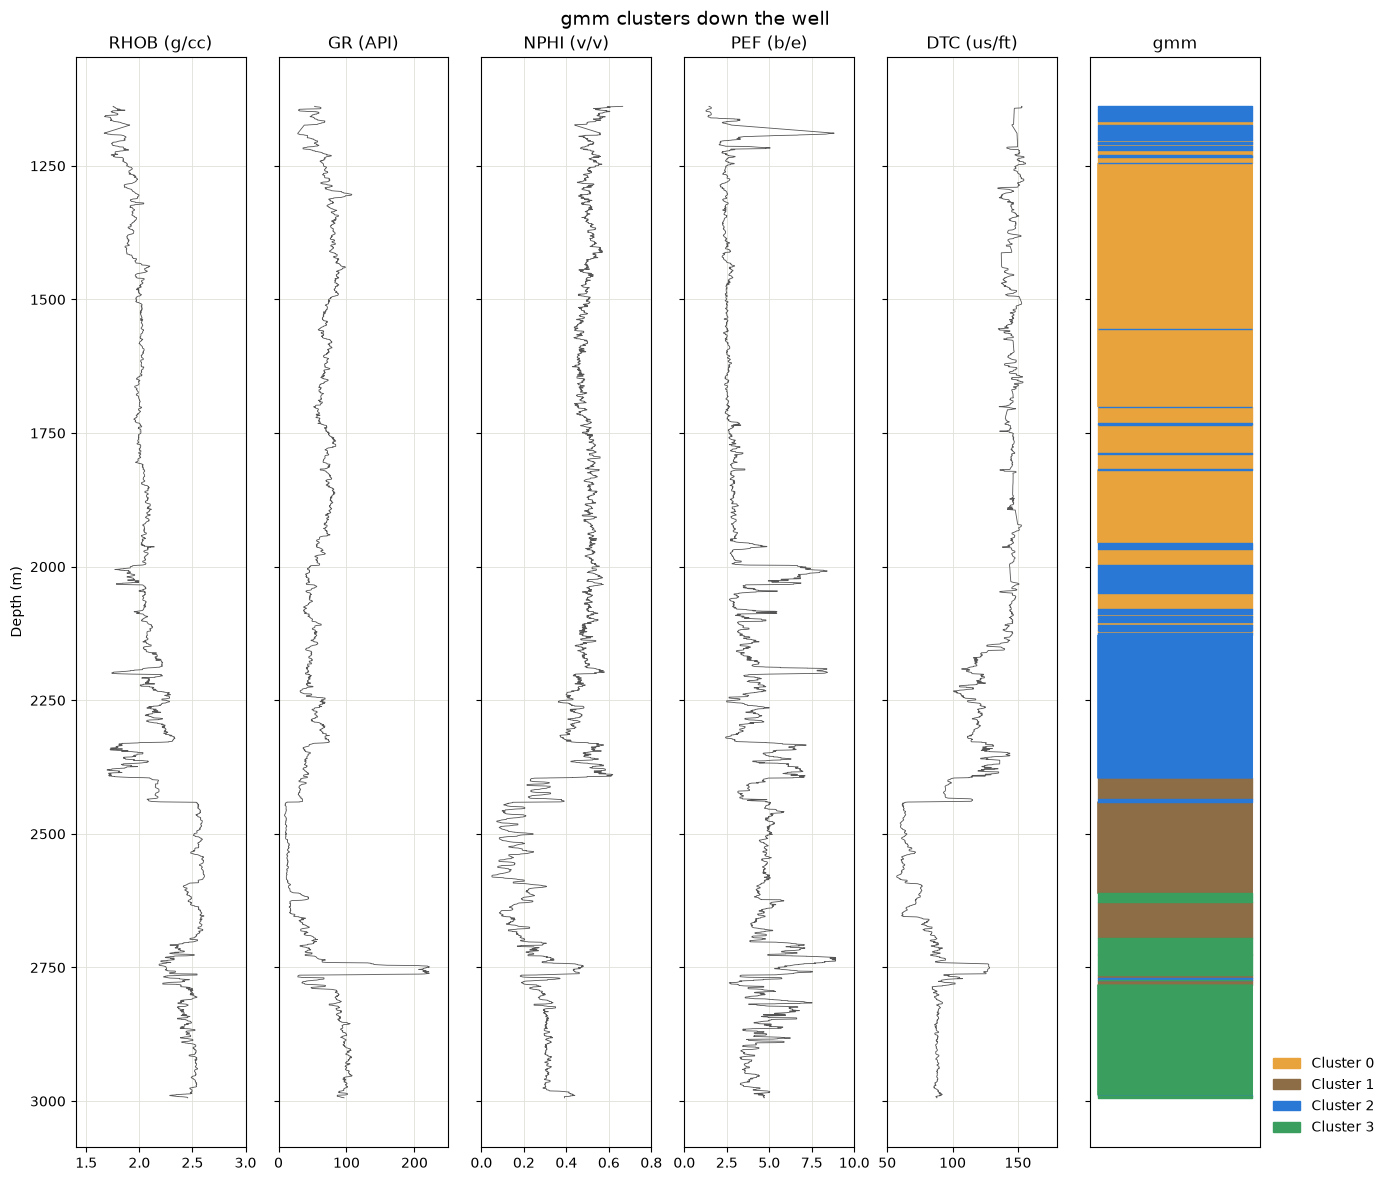

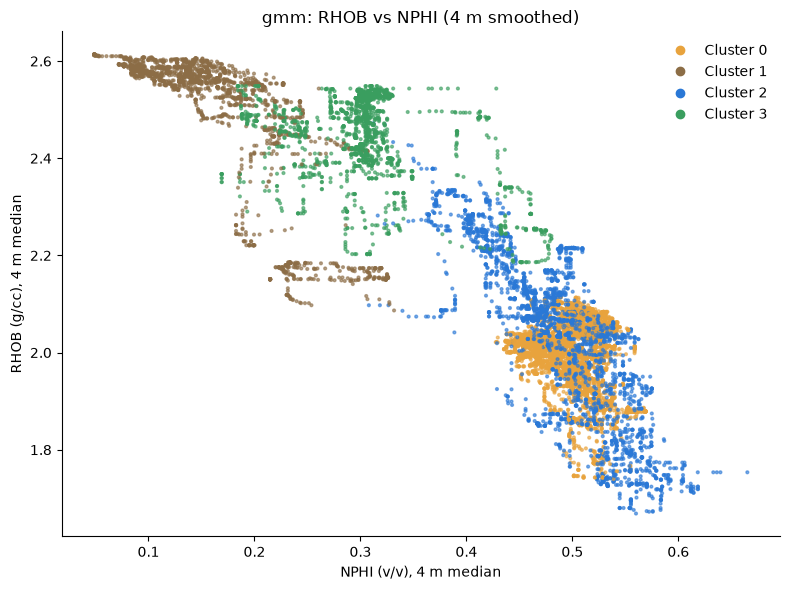

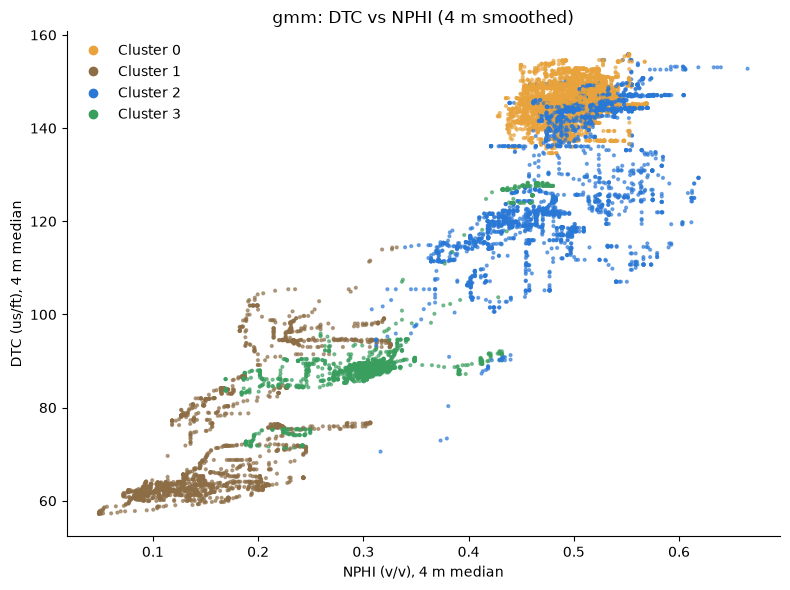

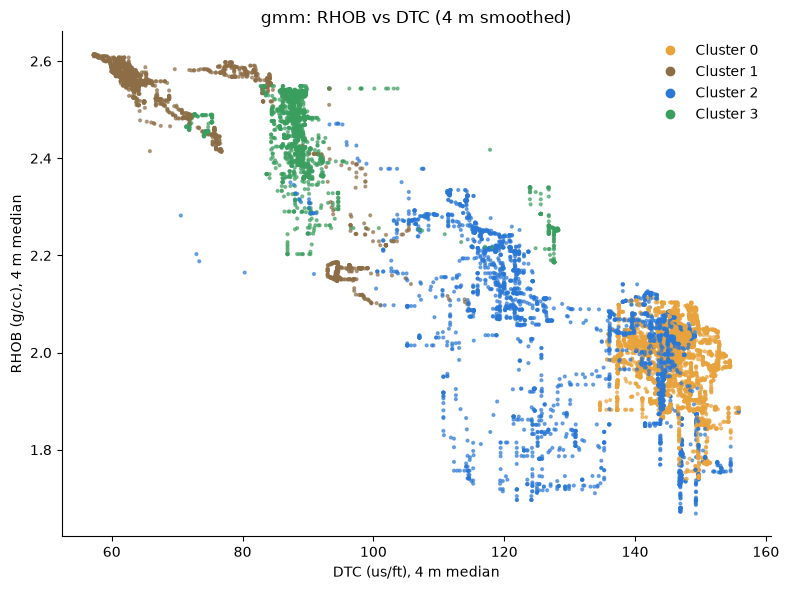

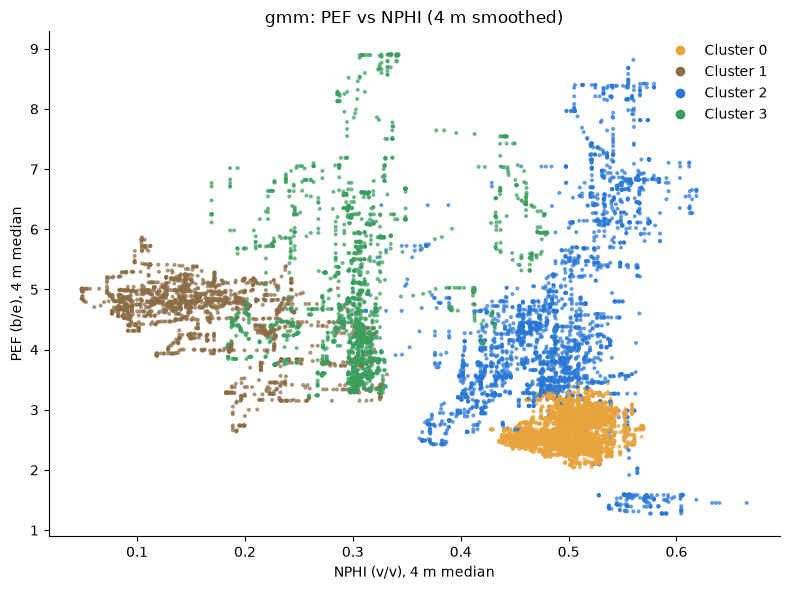

In [20]:
from matplotlib.lines import Line2D

pairs = [("NPHI", "RHOB"), ("NPHI", "DTC"), ("DTC", "RHOB"), ("NPHI", "PEF")]

def plot_crossplots(method):
    rows = features[model_rows]
    labels = sorted(rows[method].unique())
    handles = [Line2D([], [], marker="o", linestyle="", color=cluster_colors[int(label)],
                      label=f"Cluster {int(label)}") for label in labels]
    for x, y in pairs:
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.scatter(rows[f"{x}_4m"], rows[f"{y}_4m"],
                   c=rows[method].map(cluster_colors), s=4, alpha=0.6)
        ax.set_xlabel(f"{x} ({units[x]}), 4 m median")
        ax.set_ylabel(f"{y} ({units[y]}), 4 m median")
        ax.set_title(f"{method}: {y} vs {x} (4 m smoothed)")
        ax.legend(handles=handles, frameon=False)
        ax.spines[["top", "right"]].set_visible(False)
        plt.tight_layout()
        plt.show()

plot_well("gmm")
plot_crossplots("gmm")



### Gaussian Mixture summary

**What it does differently.** KMeans forces round groups of similar size. A Gaussian Mixture lets each group be
a stretched oval of its own size and gives every depth a probability of belonging to each group. Same 12,202
rows, same 4 m smoothed and scaled curves, **k = 4** so it compares with KMeans like for like.

**Picking k didn't work here.** BIC (lower = better) kept falling all the way to k = 8 instead of bottoming out,
which happens when the data is one gradual trend rather than separate blobs. Silhouette was highest at k = 2
(0.514), but 2 groups merge the carbonate and the compacted shale, so 4 was kept.

| Cluster | Estimated rock | Pattern | Middle depth |
|---|---|---|---|
| 1 | Soft shale | 2.01, NPHI 0.50, PEF 2.6, DTC 146 | ~1623 m |
| 0 | Shale, higher PEF | 2.04, NPHI 0.49, **PEF 4.3**, DTC 128 | ~2192 m |
| 2 | Limestone / chalk | 2.55, GR 15, NPHI 0.16, DTC 66 | ~2547 m |
| 3 | Compacted shale | 2.48, GR 93, NPHI 0.30, DTC 88 | ~2845 m |

**Result.** The same three rocks as KMeans, which is a good sign. The fourth group is used differently: instead
of isolating the bad high-PEF readings, GMM found a real change inside the shale around **2000–2400 m** and
absorbed the bad readings into it. Silhouette 0.446, below KMeans (0.607), so it is weaker at separating groups
and weaker for spotting bad data, but it adds a possible boundary near 2000 m.


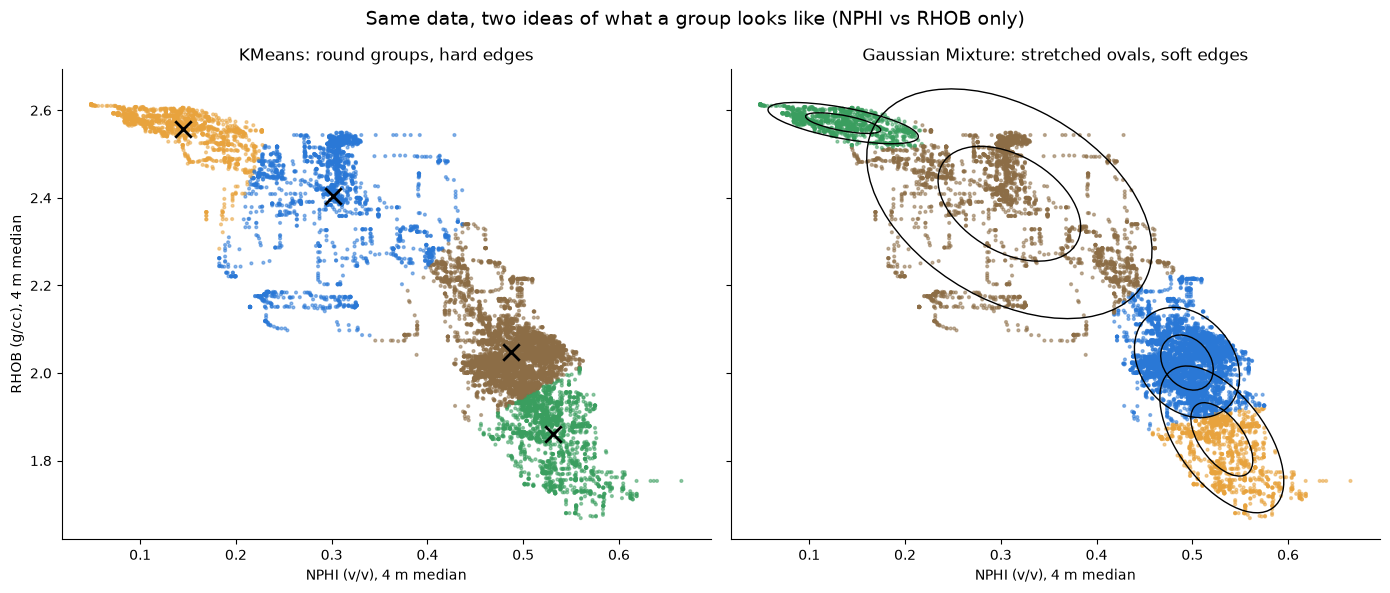

In [21]:
from matplotlib.patches import Ellipse

demo_cols = ["NPHI_4m", "RHOB_4m"]
demo = scaled.loc[model_rows, demo_cols].to_numpy()
shown = features.loc[model_rows, demo_cols].to_numpy()

# turn the scaled model numbers back into real units for the chart
i = [smooth_cols.index(col) for col in demo_cols]
scale, centre = scaler.scale_[i], scaler.center_[i]

km_demo = KMeans(n_clusters=4, n_init=10, random_state=42).fit(demo)
gm_demo = GaussianMixture(n_components=4, n_init=3, random_state=42).fit(demo)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, labels, name in [(axes[0], km_demo.labels_, "KMeans: round groups, hard edges"),
                         (axes[1], gm_demo.predict(demo), "Gaussian Mixture: stretched ovals, soft edges")]:
    ax.scatter(shown[:, 0], shown[:, 1], c=[cluster_colors[l] for l in labels], s=4, alpha=0.5)
    ax.set_xlabel("NPHI (v/v), 4 m median")
    ax.set_title(name)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("RHOB (g/cc), 4 m median")

km_centres = km_demo.cluster_centers_ * scale + centre
axes[0].scatter(km_centres[:, 0], km_centres[:, 1], marker="x", s=140, c="black", linewidths=2)

for mean, cov in zip(gm_demo.means_, gm_demo.covariances_):
    cov = cov * np.outer(scale, scale)
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(vecs[1, -1], vecs[0, -1]))
    for n_std in (1, 2):
        width, height = 2 * n_std * np.sqrt(vals[::-1])
        axes[1].add_patch(Ellipse(mean * scale + centre, width, height, angle=angle,
                                  facecolor="none", edgecolor="black", linewidth=1))

fig.suptitle("Same data, two ideas of what a group looks like (NPHI vs RHOB only)", fontsize=14)
plt.tight_layout()
plt.show()


In [22]:
from sklearn.cluster import HDBSCAN

hdb = HDBSCAN(min_cluster_size=200, copy=True).fit(X)

features.loc[model_rows, "hdbscan"] = hdb.labels_

profile = features.loc[model_rows].groupby("hdbscan")[curves].median().round(2)
profile["rows"] = features.loc[model_rows, "hdbscan"].value_counts().sort_index()
profile


,RHOB,GR,NPHI,PEF,DTC,rows
hdbscan,,,,,,
-1.0,2.23,45.42,0.37,5.54,98.95,1205
0.0,2.50,96.18,0.31,4.19,88.10,1229
1.0,2.02,65.76,0.50,2.80,144.64,7956
2.0,2.56,14.41,0.15,4.73,64.53,1714


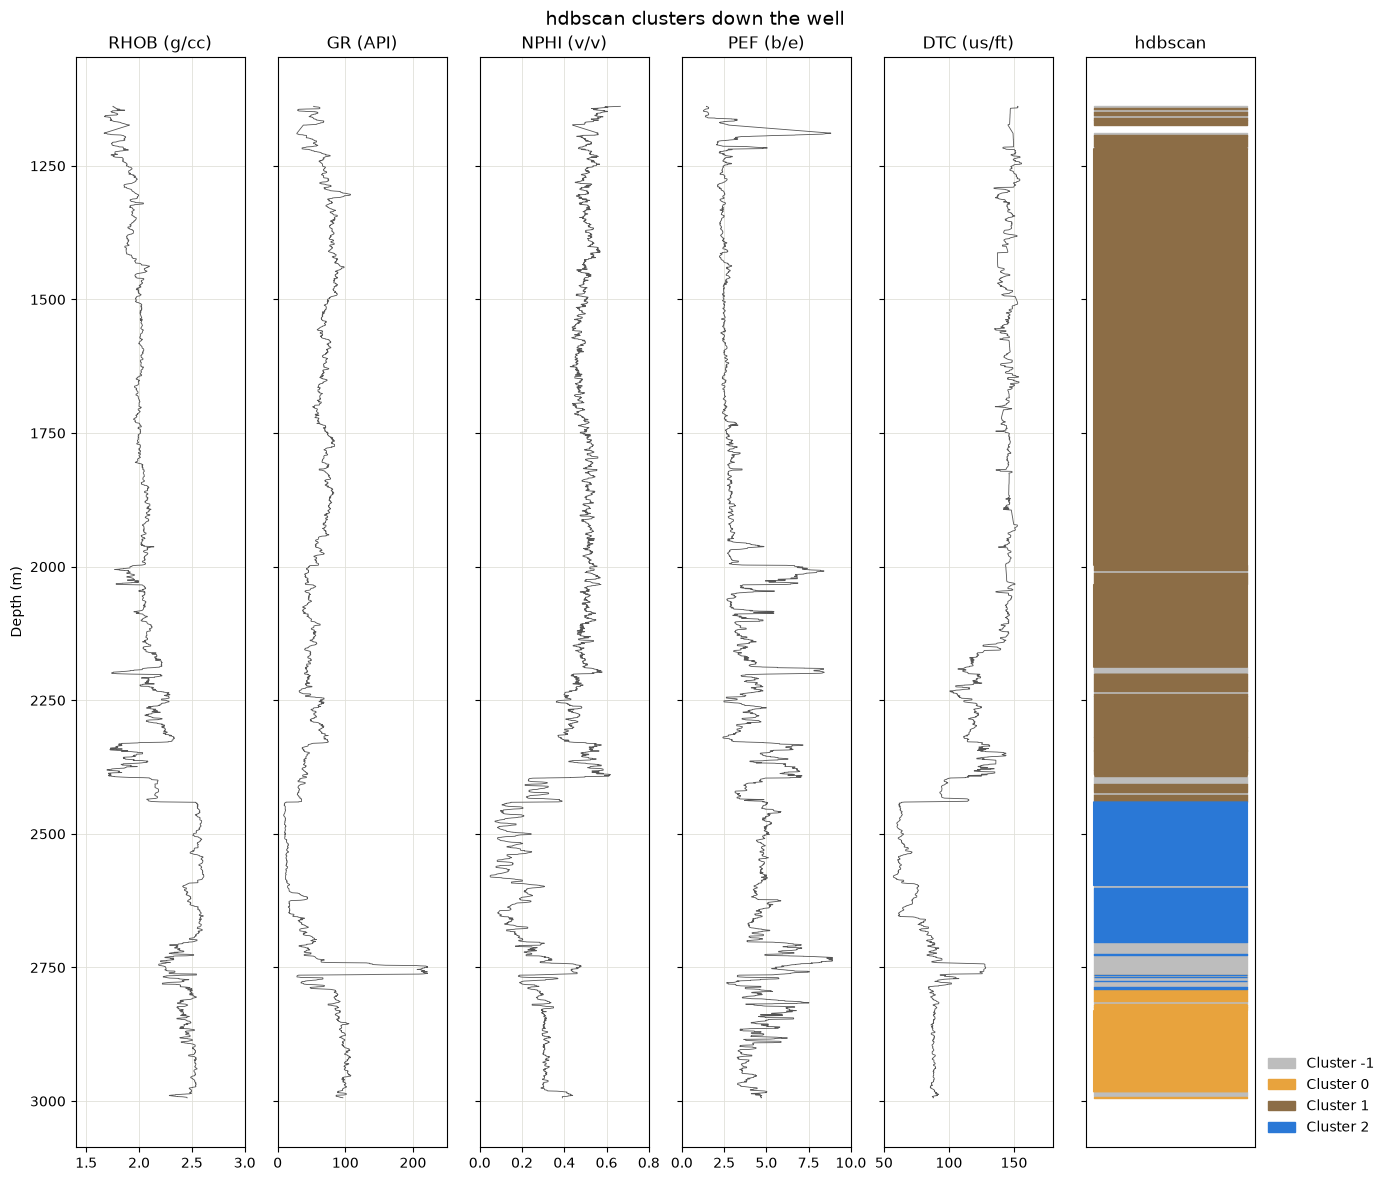

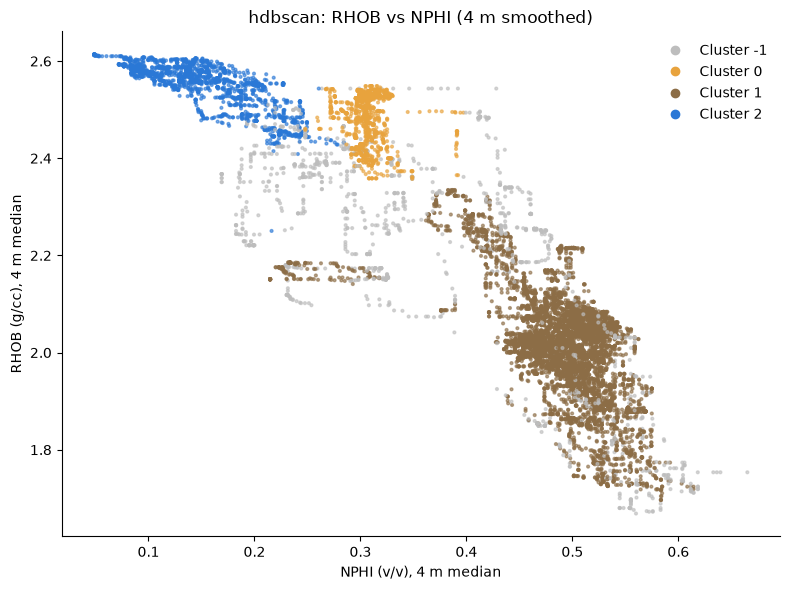

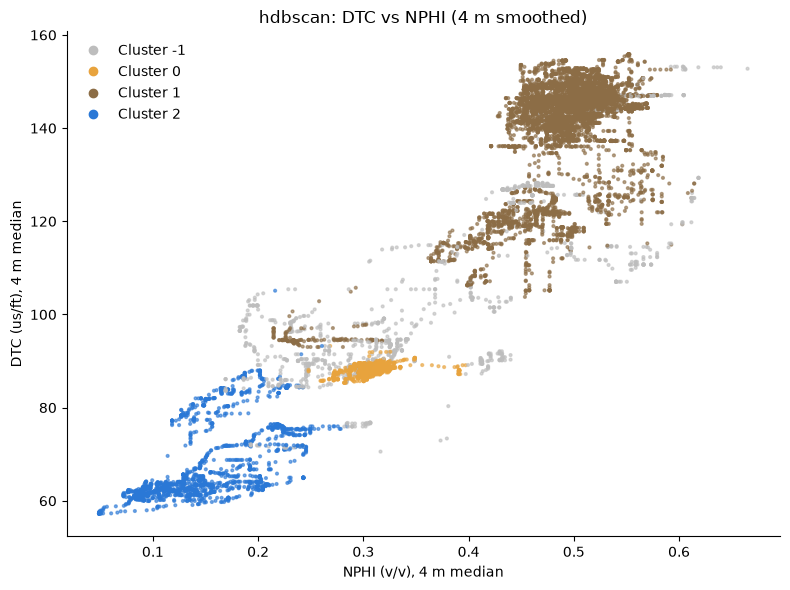

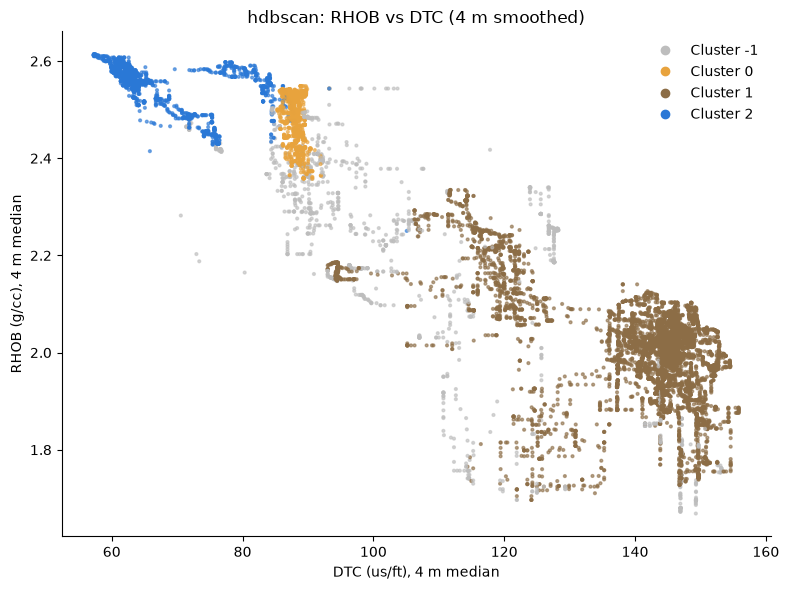

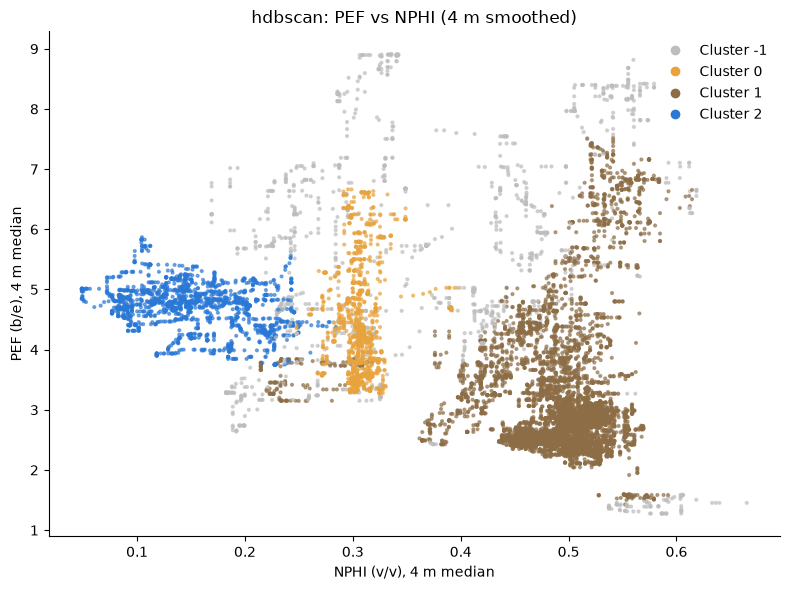

In [23]:
plot_well("hdbscan")
plot_crossplots("hdbscan")


In [24]:
noise = features.loc[model_rows & (features["hdbscan"] == -1)]

print("Noise rows:", len(noise), f"({len(noise) / model_rows.sum():.1%} of the clustered rows)")
print("\nWhich KMeans cluster the noise rows came from:")
print(noise["kmeans"].value_counts().sort_index())
print("\nNoise rows with PEF > 10:", (noise["PEF"] > 10).sum())
print("Noise rows with RHOB < 1.5:", (noise["RHOB"] < 1.5).sum())


Noise rows: 1205 (10.0% of the clustered rows)

Which KMeans cluster the noise rows came from:
kmeans
0.0    114
1.0    424
2.0    360
3.0    307
Name: count, dtype: int64

Noise rows with PEF > 10: 0
Noise rows with RHOB < 1.5: 0


### HDBSCAN summary

**How it works.** It measures how crowded each reading is, then slowly loosens the crowding requirement and
keeps only the crowds that survive across a wide range of strictness. Anything never in a surviving crowd is
labelled **noise (-1)**. It is not told how many groups to find; the only setting is `min_cluster_size=200`
(a crowd needs ~30 m of well to count).

**Result: 3 groups on its own, plus 1,325 noise rows (10.9%).**

| Cluster | Colour | Estimated rock | Pattern | Rows |
|---|---|---|---|---|
| 0 | orange | Soft shale | RHOB 2.02, GR 66, NPHI 0.50, DTC 145 | 7,954 |
| 1 | brown | Limestone / chalk | RHOB 2.56, GR 14, NPHI 0.15, DTC 65 | 1,711 |
| 2 | blue | Compacted shale | RHOB 2.50, GR 96, NPHI 0.31, DTC 88 | 1,212 |
| -1 | **grey** | **Noise** | RHOB 2.21, PEF 5.85, DTC 102 — in between everything | 1,325 |

**How to read the charts**
- **Grey = noise (-1).** Nothing has been removed: all 12,202 rows are plotted, and grey simply marks the rows
  HDBSCAN could not place in any crowd.
- **Well plot:** the 5 tracks are the smoothed curves with depth going down; the last column is a colour strip
  showing which group each depth landed in. Orange runs ~1139–2440 m, brown ~2440–2790 m, blue ~2790–2994 m.
  The colour changes line up with real jumps in RHOB, NPHI and DTC. The grey stripes sit at those changeovers
  and around the PEF spikes near 1200 m and 2000–2400 m.
- **Crossplots:** depth is dropped; each dot is one depth placed by its two smoothed readings. These show why
  the groups differ — dense low-porosity brown at one end, light high-porosity orange at the other. Grey dots
  sit in the empty lanes between the coloured blobs, which is exactly what "no company" looks like.

**Same three rocks as KMeans and GMM**, found without being told how many to look for. That is the strongest
confirmation so far that these three sections are real.

**What the noise is** — two different things mixed together:
- **164 rows with PEF > 10**, the readings already flagged in the EDA. Likely bad data.
- The rest are mostly **transition depths** where one layer grades into the next, so the readings sit halfway
  between two rocks. The noise came from all four KMeans clusters (382 / 165 / 453 / 325), which fits.

Noise means "not enough similar readings to be sure", not "wrong". A genuinely thin or unusual layer would also
land here, so these 1,325 rows go to the cleaning notebook as a **review list, not a delete list**.


In [25]:
from sklearn.cluster import AgglomerativeClustering
from scipy.sparse import diags_array

n = len(X)
depth_chain = diags_array([np.ones(n - 1), np.ones(n - 1)], offsets=[-1, 1], shape=(n, n))

agglo = AgglomerativeClustering(n_clusters=4, linkage="ward", connectivity=depth_chain).fit(X)

features.loc[model_rows, "agglo"] = agglo.labels_

profile = features.loc[model_rows].groupby("agglo")[curves].median().round(2)
profile["top (m)"] = features.loc[model_rows].groupby("agglo")["DEPTH_MD"].min()
profile["bottom (m)"] = features.loc[model_rows].groupby("agglo")["DEPTH_MD"].max()
profile["rows"] = features.loc[model_rows, "agglo"].value_counts().sort_index()
profile


,RHOB,GR,NPHI,PEF,DTC,top (m),bottom (m),rows
agglo,,,,,,,,
0.0,2.48,95.66,0.31,4.30,88.51,2741.088,2993.864,1664
1.0,2.06,47.06,0.49,4.02,127.69,1997.200,2395.288,2616
2.0,2.54,17.09,0.18,4.74,70.42,2395.440,2740.936,2274
3.0,2.00,71.17,0.50,2.60,146.18,1138.704,1997.048,5550


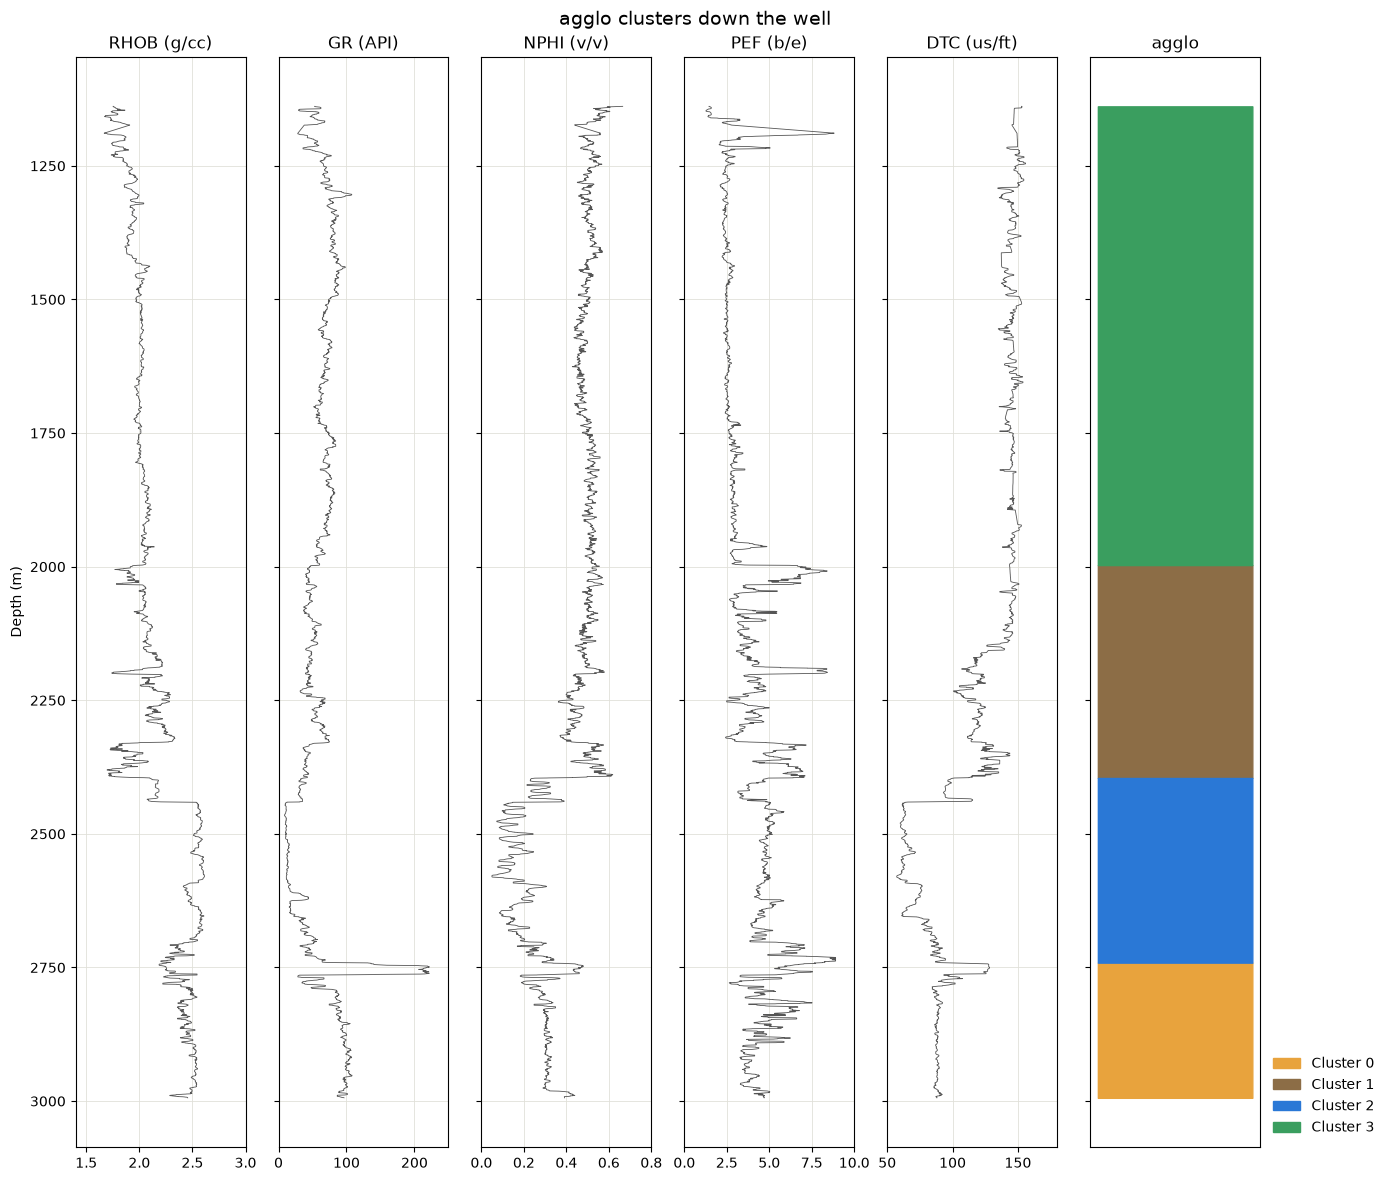

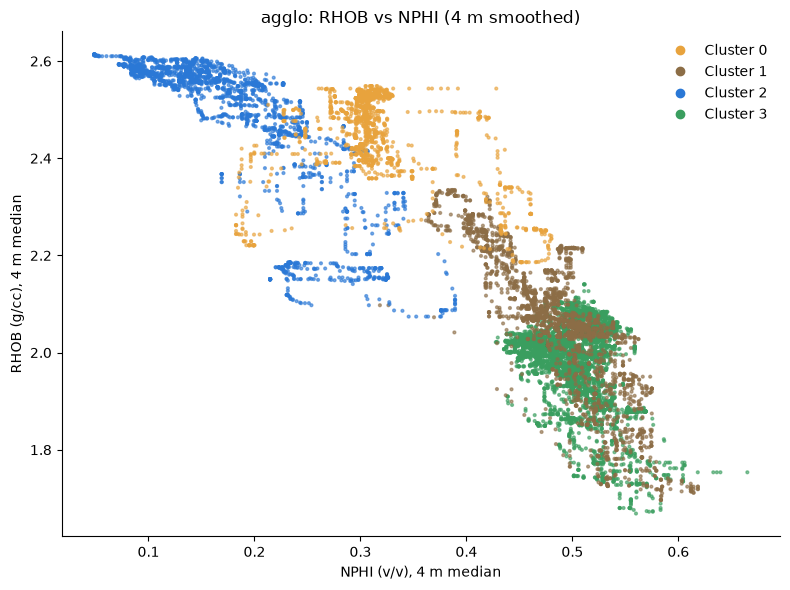

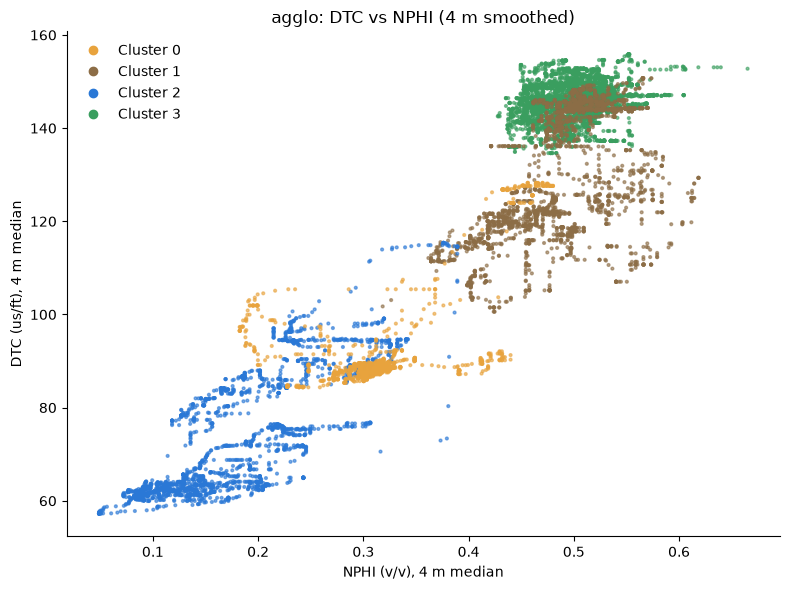

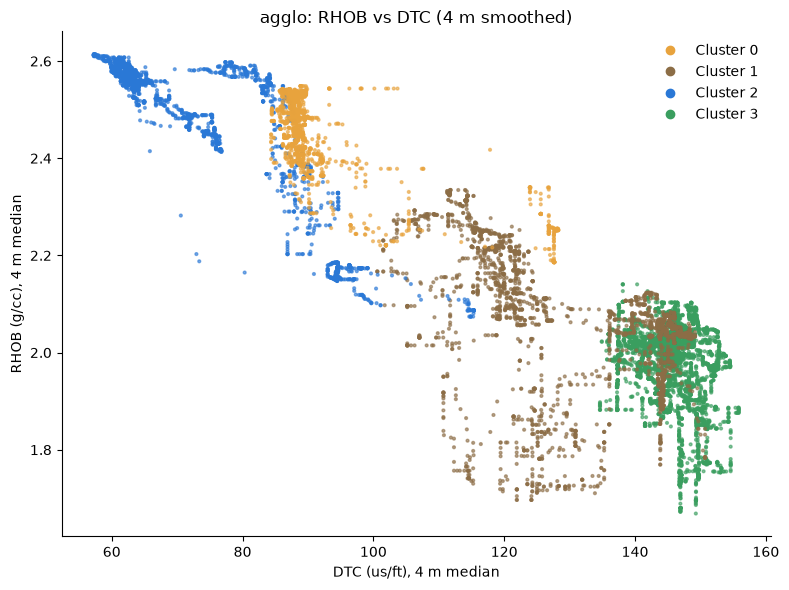

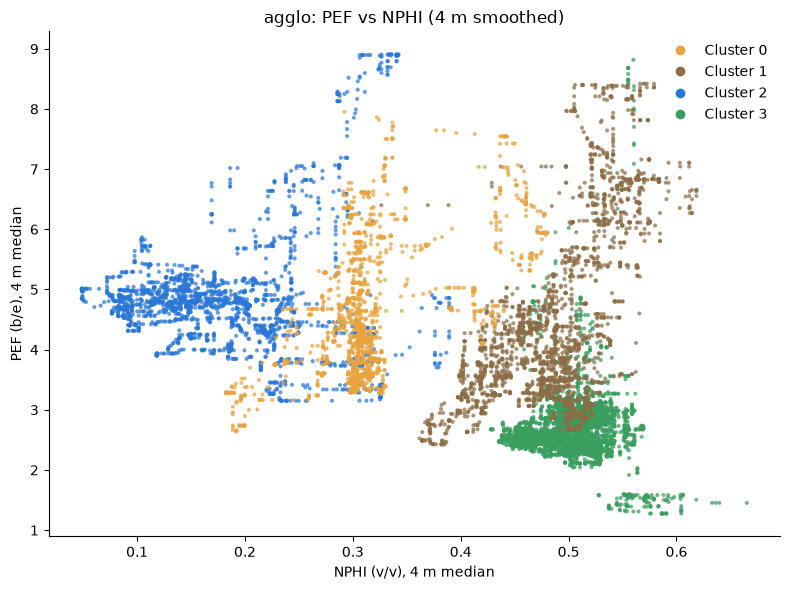

In [26]:
plot_well("agglo")
plot_crossplots("agglo")


### Agglomerative with depth — summary

**What it does.** Every reading starts as its own group, and the two most similar neighbours keep merging until
4 are left. The extra rule: a reading may only merge with the one **directly above or below it**, so groups can
only grow up and down the well. The result is proper layers with a top and a bottom.

| Layer | Depth | Estimated rock | Why |
|---|---|---|---|
| 0 (orange) | 1138.7–1997.0 m | Soft shale | light 2.00, porous 0.50, slow 146 |
| 3 (green) | 1997.2–2395.0 m | Shale, but different | same softness, **PEF 2.6 → 4.0**, faster 128 |
| 2 (blue) | 2395.1–2740.9 m | Limestone / chalk | dense 2.54, GR 17, fast 70 |
| 1 (brown) | 2741.1–2993.9 m | Compacted shale | dense 2.48, GR 96 |

**Boundaries: 1997.2, 2395.1, 2741.1 m.** The last two are the same ones KMeans found without ever seeing
depth, so they are real. **1997.2 m is new**: the upper shale is really two shales, split by PEF.

**Reading the charts.** The well plot is 4 solid blocks, no scattered bands. On RHOB vs NPHI, orange and green
overlap because both are soft shale; on PEF vs NPHI they separate. The boxy edges come from the depth rule.

**Weakness:** it cannot flag bad readings — a stray row has nowhere to go, so the high-PEF rows got absorbed
into layer 0. Use HDBSCAN for that, this one for boundaries.


In [27]:
from sklearn.metrics import adjusted_rand_score

methods = ["kmeans", "gmm", "hdbscan", "agglo"]
rows = features[model_rows]

scores = []
for method in methods:
    labels = rows[method]
    clustered = labels != -1
    sil = silhouette_score(X[clustered], labels[clustered], sample_size=5000, random_state=42)
    continuity = (labels.to_numpy()[1:] == labels.to_numpy()[:-1]).mean()
    scores.append({"method": method,
                   "clusters": labels[clustered].nunique(),
                   "noise rows": int((~clustered).sum()),
                   "silhouette": round(sil, 3),
                   "continuity": round(continuity, 4)})

pd.DataFrame(scores)


,method,clusters,noise rows,silhouette,continuity
0,kmeans,4,0,0.562,0.9957
1,gmm,4,0,0.441,0.9951
2,hdbscan,3,1205,0.608,0.9922
3,agglo,4,0,0.462,0.9998


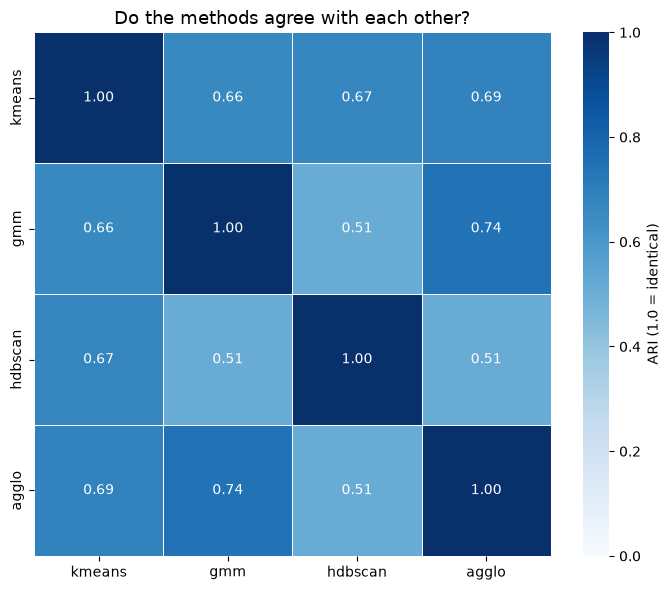

,kmeans,gmm,hdbscan,agglo
kmeans,1.00,0.66,0.67,0.69
gmm,0.66,1.00,0.51,0.74
hdbscan,0.67,0.51,1.00,0.51
agglo,0.69,0.74,0.51,1.00


In [28]:
agreement = pd.DataFrame(index=methods, columns=methods, dtype=float)
for a in methods:
    for b in methods:
        agreement.loc[a, b] = adjusted_rand_score(rows[a], rows[b])

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(agreement.astype(float), annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            linewidths=0.5, linecolor="white", cbar_kws={"label": "ARI (1.0 = identical)"}, ax=ax)
ax.set_title("Do the methods agree with each other?", fontsize=13)
plt.tight_layout()
plt.show()

agreement.round(2)




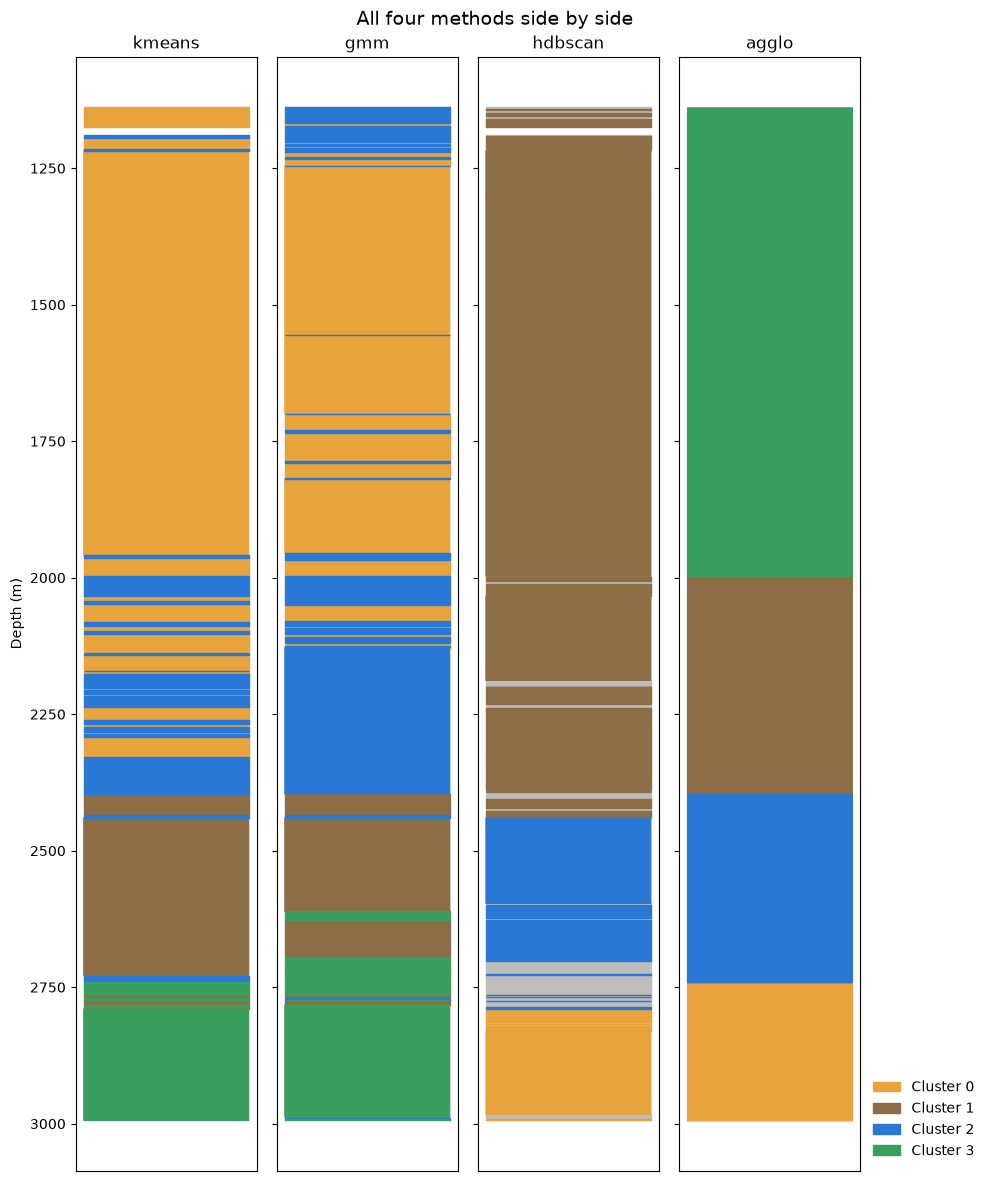

In [29]:
fig, axes = plt.subplots(1, len(methods), figsize=(10, 12), sharey=True)
for ax, method in zip(axes, methods):
    for label in sorted(rows[method].unique()):
        ax.fill_betweenx(rows["DEPTH_MD"], 0, 1, where=rows[method] == label,
                         color=cluster_colors[int(label)], label=f"Cluster {int(label)}")
    ax.set_xticks([])
    ax.set_title(method)
axes[0].set_ylabel("Depth (m)")
axes[0].invert_yaxis()
axes[-1].legend(loc="lower left", bbox_to_anchor=(1, 0), frameon=False)
fig.suptitle("All four methods side by side", fontsize=14)
plt.tight_layout()
plt.show()


In [30]:
window_2m = 13

smooth_2m = pd.DataFrame({f"{col}_2m": df[col].rolling(window=window_2m, center=True,
                                                       min_periods=window_2m // 2 + 1).median()
                          for col in curves})
scaled_2m = pd.DataFrame(RobustScaler().fit_transform(smooth_2m),
                         columns=smooth_2m.columns, index=smooth_2m.index)
X_2m = scaled_2m[model_rows]

compare = []
for name, data in [("4 m", X), ("2 m", X_2m)]:
    labels = KMeans(n_clusters=4, n_init=10, random_state=42).fit_predict(data)
    compare.append({"window": name,
                    "silhouette": round(silhouette_score(data, labels, sample_size=5000, random_state=42), 3),
                    "continuity": round((labels[1:] == labels[:-1]).mean(), 4)})

pd.DataFrame(compare)


ValueError: Input X contains NaN.
KMeans does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

## BETA RESULTS

### What we were trying to do

A well was drilled and five instruments were lowered down it, recording a reading every **0.152 m** all the way
to 3,272 m. Nobody labelled what rock is at each depth, and that is what we want to estimate. The idea: depths
made of the same rock give similar readings, so if we group similar readings together, each group should be a
rock type.

### How the data was prepared

1. **Smoothing.** Raw readings jump around because of the tool, not the rock. For each depth we took the middle
   value (median) of the readings within 2 m above and 2 m below it — a **4 m window, 27 rows**. Wobbles shorter
   than ~2 m disappear, real layers stay.
2. **Scaling.** GR counts up to 250 while NPHI stays under 1. Without fixing that, GR would decide everything,
   so every curve was rescaled to a common size. The readings do not change, only their units.
3. **Rows used.** Grouping needs all five readings present, so the **12,202 rows from 1138.7 to 2993.9 m** went
   in. Nothing was deleted — the rest simply have no group in this beta.

### The four methods, and what each one is for

| Method | How it groups | What it is good at |
|---|---|---|
| **KMeans** | You say how many groups; it drops that many centre points and each depth joins its nearest, then the centres move to the middle of their members and it repeats until nothing changes | Simple and clear-cut. Gave the cleanest groups |
| **Gaussian Mixture** | Same idea, but groups can be stretched shapes, and each depth gets a *percentage* chance of belonging to each one instead of a hard yes/no | Handles depths that sit between two rocks |
| **HDBSCAN** | Looks for crowds of similar readings. Decides the number of groups itself, and a reading with nothing similar nearby is labelled **noise** instead of being forced into a group | Finding odd or broken readings |
| **Agglomerative (with depth)** | Every reading starts alone and keeps merging with its most similar neighbour until 4 remain — but it may only merge with the reading directly **above or below**, so groups grow up and down the well | Clean layer boundaries, like a geologist's log |

### What they found

All four agree, and the first three were never told the depth — they only saw the readings. They still came out
as depth sections, which is the strongest evidence we can get without labels:

| Depth | Estimated rock | Why |
|---|---|---|
| 1138.7 – ~1997 m | Soft shale / mudstone | light, very porous, slow sound |
| ~1997 – ~2395 m | Shale, a second type | same softness, but PEF rises (2.6 → 4.0) |
| ~2395 – ~2741 m | Limestone / chalk | dense, hardly any clay (GR 17), fast |
| ~2741 – 2993.9 m | Compacted shale | dense, but plenty of clay (GR 96) |

The boundaries at **2395 m and 2741 m** show up in four curves at once, and two completely different methods put
them at the same depth, so they are real changes in the rock. The **1997 m** boundary was found only by the
depth-aware methods.

These are interpretations of instrument behaviour, not confirmed rock. The dataset has no labels, so there is
nothing to check them against.

### Scores

| Method | Groups | Noise | Separation (silhouette) | Layer continuity |
|---|---|---|---|---|
| KMeans | 4 | 0 | 0.607 | 0.9966 |
| Gaussian Mixture | 4 | 0 | 0.446 | 0.9957 |
| HDBSCAN | 3 | 1,325 | 0.607* | 0.9925 |
| Agglomerative + depth | 4 | 0 | 0.434 | 0.9998 |

\* only counts the rows it kept. **Separation** above 0.5 means clearly distinct groups. **Continuity** is how
often a depth has the same label as the one below it — all four are above 0.99, so the groups do not flicker.

**Window check:** rerunning with a 2 m window instead of 4 m barely changed anything (0.600 vs 0.607), so the
layers are genuine and not a side effect of the smoothing. 4 m stays.

### What to fix in the cleaning notebook

1. **KMeans cluster 0 (931 rows).** The lightest rock in the well (RHOB 1.88) but also the highest PEF (7.06).
   Real rock does not do that, and these sit exactly on the PEF > 10 readings flagged in the EDA. Probably a
   washed-out hole or a tool problem. HDBSCAN independently flagged 41% of this cluster as noise, against 2% of
   the shale.
2. **HDBSCAN noise (1,325 rows).** A mix: 164 are the PEF > 10 readings, the rest are mostly boundary depths
   where one layer grades into the next. A **review list, not a delete list** — a genuinely thin layer looks the
   same as a bad reading to this method.
3. **RHOB < 1.5 (976 rows from the EDA),** nearly all above 1138 m, so they never entered this clustering.
4. **DTC drop at 1290.6–1293.3 m** — RHOB and GR barely move there, so it is likely a sonic error.
5. **Missing sections:** NPHI above 1138.6 m, PEF below 2994.0 m, DTC below 3259.9 m.
6. **The 0.76 m depth gap at 2100.7 m.**

### After cleaning

Rerun this notebook on the cleaned data. The steps do not change, only the input file. The groups should tighten
and cluster 0 should disappear — if it does, that confirms it was bad data rather than rock.
